# *ALGORITMA LSTM UNTUK PREDIKSI HASIL PRODUKSI TANAMAN SAYURAN DAN BUAH-BUAHAB DI KECAMATAN CISARUA KABUPATEN BANDUNG BARAT*


## 1. Konfigurasi & Import Library


In [64]:
# --- 1.1 Import library ------------------------------------------------------
import os, json, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (LSTM, Dense, Dropout,
                                      Input, Embedding, Concatenate, Flatten)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('Semua library berhasil diimport')


TensorFlow version: 2.20.0
Semua library berhasil diimport


In [65]:
# --- 1.2 Random seed & konfigurasi global ------------------------------------

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Path file (ubah jika file disimpan di folder lain / Google Drive)
FILE_PROD  = 'dataset/Data_Produksi_2023_2026_Gabungan.xlsx'
FILE_CUACA = 'dataset/Data_Cuaca.xlsx'
FILE_PUPUK = 'dataset/Data_Pupuk.xlsx'

# Folder untuk menyimpan seluruh artefak (dibuat otomatis jika belum ada)
ARTIFACT_DIR = 'artefak_model'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# Parameter utama penelitian (KEPUTUSAN YANG SUDAH DITETAPKAN)
TIMESTEP = 3          # 3 bulan sebelumnya -> prediksi 1 bulan berikutnya (sesuai Bab III)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15    # sisanya (0.15) otomatis jadi test

BULAN_MAP = {
    'Januari':1, 'Februari':2, 'Febuari':2,  # 'Febuari' = typo yang ditemukan di data asli
    'Maret':3, 'April':4, 'Mei':5, 'Juni':6,
    'Juli':7, 'Agustus':8, 'September':9,
    'Oktober':10, 'November':11, 'Desember':12
}

print('Konfigurasi selesai. TIMESTEP =', TIMESTEP)


Konfigurasi selesai. TIMESTEP = 3


## 2. Pembacaan Data


In [66]:
# --- 2.1 Baca Data Produksi ---------------------------------------------------
if not os.path.exists(FILE_PROD):
    raise FileNotFoundError(
        f"File '{FILE_PROD}' tidak ditemukan. "
        f"Pastikan file sudah diupload ke Colab dengan nama yang sama persis."
    )

df_prod = pd.read_excel(FILE_PROD)
print(f'Data produksi: {df_prod.shape[0]} baris, {df_prod.shape[1]} kolom')
print('Kolom:', df_prod.columns.tolist())
df_prod.head(3)


Data produksi: 1020 baris, 14 kolom
Kolom: ['No', 'Tahun', 'Bulan', 'Kode', 'Nama Komoditas', 'Luas Tan Akhir Bulan Lalu', 'Luas Panen Habis', 'Luas Panen Belum Habis', 'Luas Rusak', 'Luas Tambah Tanam', 'Luas Tan Akhir', 'Produksi Habis (Kw)', 'Produksi Belum Habis (Kw)', 'Harga Jual Petani (Rp/Kg)']


,No,Tahun,Bulan,Kode,Nama Komoditas,Luas Tan Akhir Bulan Lalu,Luas Panen Habis,Luas Panen Belum Habis,Luas Rusak,Luas Tambah Tanam,Luas Tan Akhir,Produksi Habis (Kw),Produksi Belum Habis (Kw),Harga Jual Petani (Rp/Kg)
0,1,2023,Januari,BWD,Bawang Daun,9,1,0,0,2,10,180.0,0,5000
1,2,2023,Januari,BMR,Bawang Merah,0,0,0,0,0,0,0.0,0,0
2,3,2023,Januari,BPT,Bawang Putih,0,0,0,0,0,0,0.0,0,0


In [67]:
# --- 2.2 Baca Data Cuaca (1 sheet per tahun: 2023, 2024, 2025, 2026) ---------
if not os.path.exists(FILE_CUACA):
    raise FileNotFoundError(f"File '{FILE_CUACA}' tidak ditemukan.")

cuaca_list = []
for tahun in [2023, 2024, 2025, 2026]:
    df_tmp = pd.read_excel(FILE_CUACA, sheet_name=str(tahun), header=None)
    # Baris index 0 = judul rekap, baris index 1 = header kolom, data mulai index 2
    df_tmp.columns = df_tmp.iloc[1].values
    df_tmp = df_tmp.iloc[2:].reset_index(drop=True)
    df_tmp.columns = [str(c).replace('\n', ' ').strip() for c in df_tmp.columns]
    df_tmp['Tahun'] = tahun
    # Buang baris ringkasan/total yang mungkin ikut terbaca (kolom 'No' harus berupa angka)
    df_tmp = df_tmp[df_tmp['No'].apply(lambda x: str(x).strip().isdigit())]
    cuaca_list.append(df_tmp)

df_cuaca = pd.concat(cuaca_list, ignore_index=True)
print(f'Data cuaca gabungan: {df_cuaca.shape[0]} baris, {df_cuaca.shape[1]} kolom')
print('Kolom:', df_cuaca.columns.tolist())
df_cuaca.head(3)


Data cuaca gabungan: 39 baris, 11 kolom
Kolom: ['No', 'Bulan', 'Suhu Maks (°C)', 'Suhu Min (°C)', 'Suhu Rata-rata (°C)', 'Kec. Angin Maks (km/h)', 'Curah Hujan* (mm)', 'Kelembaban* (%)', 'Hari Hujan (est.)', 'Kategori Cuaca', 'Tahun']


,No,Bulan,Suhu Maks (°C),Suhu Min (°C),Suhu Rata-rata (°C),Kec. Angin Maks (km/h),Curah Hujan* (mm),Kelembaban* (%),Hari Hujan (est.),Kategori Cuaca,Tahun
0,1,Januari,25.9,20.1,22.5,25.9,282.1,95.9,28,Basah,2023
1,2,Februari,24.9,20.1,22.1,24.9,305.2,96.9,31,Sangat Basah,2023
2,3,Maret,26.2,20.2,22.7,26.2,316.2,96.3,32,Sangat Basah,2023


In [68]:
# --- 2.3 Baca Data Pupuk ------------------------------------------------------
if not os.path.exists(FILE_PUPUK):
    raise FileNotFoundError(f"File '{FILE_PUPUK}' tidak ditemukan.")

df_pupuk = pd.read_excel(FILE_PUPUK)  # ambil sheet pertama secara otomatis (tidak perlu sebut nama sheet)
# Ada baris duplikat yang isinya nama kolom itu sendiri (artefak dari Excel) -> dibuang
df_pupuk = df_pupuk[df_pupuk['Jenis_Tanaman'] != 'Jenis_Tanaman'].reset_index(drop=True)

print(f'Data pupuk: {df_pupuk.shape[0]} baris, {df_pupuk.shape[1]} kolom')
df_pupuk[['Jenis_Tanaman', 'Kategori', 'Total_Pupuk_Kg']]


Data pupuk: 26 baris, 17 kolom


,Jenis_Tanaman,Kategori,Total_Pupuk_Kg
0,Bawang Daun,Sayuran,250
1,Bawang Merah,Sayuran,325
2,Bawang Putih,Sayuran,325
3,Kembang Kol,Sayuran,250
4,Kentang,Sayuran,325
5,Kubis,Sayuran,250
6,Petsai/Sawi,Sayuran,250
7,Wortel,Sayuran,325
8,Bayam,Sayuran,250
9,Buncis,Sayuran,400


## 3. Validasi Struktur Data


In [69]:
# --- 3.1 Validasi Data Produksi ----------------------------------------------
print('=== VALIDASI DATA PRODUKSI ===')
print(df_prod.dtypes)
print()
print('Rentang tahun:', sorted(df_prod['Tahun'].unique()))
print('Daftar bulan:', sorted(df_prod['Bulan'].unique(), key=lambda b: BULAN_MAP.get(b, 99)))
print('Jumlah komoditas unik (Nama Komoditas):', df_prod['Nama Komoditas'].nunique())
print()
print('Missing value per kolom:')
print(df_prod.isnull().sum())


=== VALIDASI DATA PRODUKSI ===
No                             int64
Tahun                          int64
Bulan                         object
Kode                          object
Nama Komoditas                object
Luas Tan Akhir Bulan Lalu      int64
Luas Panen Habis               int64
Luas Panen Belum Habis         int64
Luas Rusak                     int64
Luas Tambah Tanam              int64
Luas Tan Akhir                 int64
Produksi Habis (Kw)          float64
Produksi Belum Habis (Kw)      int64
Harga Jual Petani (Rp/Kg)      int64
dtype: object

Rentang tahun: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Daftar bulan: ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
Jumlah komoditas unik (Nama Komoditas): 29

Missing value per kolom:
No                           0
Tahun                        0
Bulan                        0
Kode                         0
Nama Komoditas           

In [70]:
# --- 3.2 Validasi Data Cuaca --------------------------------------------------
print('=== VALIDASI DATA CUACA ===')
print('Rentang tahun:', sorted(df_cuaca['Tahun'].unique()))
print('Missing value per kolom:')
print(df_cuaca.isnull().sum())


=== VALIDASI DATA CUACA ===
Rentang tahun: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Missing value per kolom:
No                        0
Bulan                     0
Suhu Maks (°C)            0
Suhu Min (°C)             0
Suhu Rata-rata (°C)       0
Kec. Angin Maks (km/h)    0
Curah Hujan* (mm)         0
Kelembaban* (%)           0
Hari Hujan (est.)         0
Kategori Cuaca            0
Tahun                     0
dtype: int64


In [71]:
# --- 3.3 Validasi Data Pupuk --------------------------------------------------
print('=== VALIDASI DATA PUPUK ===')
print('Missing value per kolom:')
print(df_pupuk.isnull().sum())
print()
print('Komoditas di data produksi tapi TIDAK ada resep pupuknya:')
nama_prod_awal  = set(df_prod['Nama Komoditas'].unique())
nama_pupuk_awal = set(df_pupuk['Jenis_Tanaman'].unique())
for n in sorted(nama_prod_awal - nama_pupuk_awal):
    print('  -', n)


=== VALIDASI DATA PUPUK ===
Missing value per kolom:
Jenis_Tanaman               0
Kategori                    0
Total_Pupuk_Kg              0
Urea_Kg                     0
ZA_Kg                       0
SP36_Kg                     0
KCl_Kg                      0
NPK_Mutiara_Kg              0
Pupuk_Kandang_Kg            0
Kapur_Dolomit_Kg            0
Keterangan                  0
Serbuk_Gergaji_Kg           0
Dedak_Padi_Kg               0
Ampas_Kedelai_Kg            0
Kapur_Pertanian_CaCO3_Kg    0
Gips_CaSO4_Kg               0
Jagung_Tepung_Kg            0
dtype: int64

Komoditas di data produksi tapi TIDAK ada resep pupuknya:
  - Cabai Besar/ TW / Teropong
  - Kacang Merah
  - Lobak


## 4. Data Cleaning


In [72]:
# --- 4.1 Konversi satuan & variabel turunan — Data Produksi -----------------
df_prod = df_prod.rename(columns={'Nama Komoditas': 'Nama'})

# Produksi asli dalam Kwintal -> dikonversi ke Kg (1 Kwintal = 100 Kg)
df_prod['Produksi_Habis_kg']     = pd.to_numeric(df_prod['Produksi Habis (Kw)'], errors='coerce').fillna(0) * 100
df_prod['Produksi_BelumHabis_kg'] = pd.to_numeric(df_prod['Produksi Belum Habis (Kw)'], errors='coerce').fillna(0) * 100
df_prod['Produksi_kg'] = df_prod['Produksi_Habis_kg'] + df_prod['Produksi_BelumHabis_kg']

# Luas panen = luas yang sudah habis dipanen + yang belum habis (masih ada tanaman produktif)
df_prod['Luas_Panen_ha'] = (
    pd.to_numeric(df_prod['Luas Panen Habis'], errors='coerce').fillna(0) +
    pd.to_numeric(df_prod['Luas Panen Belum Habis'], errors='coerce').fillna(0)
)

df_prod['Bulan_Angka'] = df_prod['Bulan'].map(BULAN_MAP)
if df_prod['Bulan_Angka'].isnull().any():
    tidak_dikenali = df_prod.loc[df_prod['Bulan_Angka'].isnull(), 'Bulan'].unique()
    raise ValueError(f'Ada nama bulan yang tidak dikenali di BULAN_MAP: {tidak_dikenali}')

print('Konversi & variabel turunan selesai.')
# Tampilkan 1 contoh baris per tahun, supaya kelihatan datanya memang lengkap 2023-2026 (bukan cuma awal)
for tahun in sorted(df_prod['Tahun'].unique()):
    print(f'--- Tahun {tahun} ---')
    display(df_prod.loc[df_prod['Tahun'] == tahun, ['Tahun','Bulan','Nama','Produksi_kg','Luas_Panen_ha']].head(1))


Konversi & variabel turunan selesai.
--- Tahun 2023 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
0,2023,Januari,Bawang Daun,18000.0,1


--- Tahun 2024 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
312,2024,Januari,Bawang Daun,60000.0,3


--- Tahun 2025 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
624,2025,Januari,Bawang Daun,18000.0,1


--- Tahun 2026 ---


,Tahun,Bulan,Nama,Produksi_kg,Luas_Panen_ha
936,2026,Januari,Bawang Daun,60000.0,3


In [73]:
# --- 4.2 Cek data duplikat (kombinasi Tahun + Bulan + Nama) ------------------
jumlah_duplikat = df_prod.duplicated(subset=['Tahun', 'Bulan', 'Nama']).sum()
print(f'Jumlah baris duplikat (Tahun+Bulan+Nama sama): {jumlah_duplikat}')

if jumlah_duplikat > 0:
    df_prod = df_prod.drop_duplicates(subset=['Tahun', 'Bulan', 'Nama'], keep='first').reset_index(drop=True)
    print(f'Duplikat dihapus. Sisa baris: {len(df_prod)}')
else:
    print('Tidak ada duplikat -> tidak ada baris yang dihapus.')


Jumlah baris duplikat (Tahun+Bulan+Nama sama): 0
Tidak ada duplikat -> tidak ada baris yang dihapus.


In [74]:
# --- 4.3 Cek missing value pada variabel target & penanganan nilai nol ------
print('Missing value pada Produksi_kg dan Luas_Panen_ha:')
print(df_prod[['Produksi_kg', 'Luas_Panen_ha']].isnull().sum())

# Jika target produksi kosong (NaN), baris tidak relevan -> dihapus (sesuai Bab III)
sebelum = len(df_prod)
df_prod = df_prod.dropna(subset=['Produksi_kg']).reset_index(drop=True)
print(f'Baris dihapus karena Produksi_kg kosong: {sebelum - len(df_prod)}')

# PENTING: produksi = 0 BUKAN missing value. Artinya komoditas itu memang tidak
# dipanen bulan tersebut (data valid, bukan data kosong) -> tetap dipertahankan,
# tapi ditandai supaya bisa ditangani khusus saat menghitung MAPE (lihat Bagian 14).
jumlah_nol = (df_prod['Produksi_kg'] == 0).sum()
df_prod['is_zero_produksi'] = (df_prod['Produksi_kg'] == 0).astype(int)
print(f'Baris dengan Produksi_kg = 0 (bulan tanpa panen): {jumlah_nol} dari {len(df_prod)} '
      f'({jumlah_nol/len(df_prod)*100:.1f}%) -> DIPERTAHANKAN, ditandai kolom is_zero_produksi')


Missing value pada Produksi_kg dan Luas_Panen_ha:
Produksi_kg      0
Luas_Panen_ha    0
dtype: int64
Baris dihapus karena Produksi_kg kosong: 0
Baris dengan Produksi_kg = 0 (bulan tanpa panen): 502 dari 1020 (49.2%) -> DIPERTAHANKAN, ditandai kolom is_zero_produksi


In [75]:
# --- 4.4 Penyeragaman nama komoditas -----------------------------------------
# Ditemukan pada tahap 3: 'Cabai Besar/ TW / Teropong' adalah penulisan lain dari 'Cabai Besar'
nama_mapping = {
    'Cabai Besar/ TW / Teropong': 'Cabai Besar',
}
df_prod['Nama'] = df_prod['Nama'].replace(nama_mapping)

print('Total komoditas unik setelah penyeragaman:', df_prod['Nama'].nunique())
print(sorted(df_prod['Nama'].unique()))


Total komoditas unik setelah penyeragaman: 28
['Bawang Daun', 'Bawang Merah', 'Bawang Putih', 'Bayam', 'Buncis', 'Cabai Besar', 'Cabai Keriting', 'Cabai Rawit', 'Jamur Lainnya', 'Jamur Merang', 'Jamur Tiram', 'Kacang Merah', 'Kacang Panjang', 'Kangkung', 'Kembang Kol', 'Kentang', 'Kubis', 'Labu Siam', 'Lobak', 'Melon', 'Mentimun', 'Paprika', 'Petsai/Sawi', 'Semangka', 'Stroberi', 'Terung', 'Tomat', 'Wortel']


In [76]:
# --- 4.5 Data Cleaning — Cuaca -----------------------------------------------
col_suhu  = [c for c in df_cuaca.columns if 'Suhu Rata' in str(c)][0]
col_hujan = [c for c in df_cuaca.columns if 'Curah Hujan' in str(c)][0]
col_bulan = [c for c in df_cuaca.columns if c == 'Bulan'][0]

df_cuaca_clean = df_cuaca[['Tahun', col_bulan, col_suhu, col_hujan]].copy()
df_cuaca_clean.columns = ['Tahun', 'Bulan', 'Suhu_Rata', 'Curah_Hujan']

for c in ['Tahun', 'Suhu_Rata', 'Curah_Hujan']:
    df_cuaca_clean[c] = pd.to_numeric(df_cuaca_clean[c], errors='coerce')
df_cuaca_clean['Bulan_Angka'] = df_cuaca_clean['Bulan'].map(BULAN_MAP)

# Isi missing value cuaca dengan forward fill (data cuaca kontinu antarwaktu) lalu backward fill untuk sisa di awal
df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']] = (
    df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']].ffill().bfill()
)

print('Missing value cuaca setelah cleaning:')
print(df_cuaca_clean[['Suhu_Rata', 'Curah_Hujan']].isnull().sum())


Missing value cuaca setelah cleaning:
Suhu_Rata      0
Curah_Hujan    0
dtype: int64


In [77]:
# --- 4.6 Data Cleaning — Pupuk -----------------------------------------------
df_pupuk_clean = df_pupuk[['Jenis_Tanaman', 'Total_Pupuk_Kg']].copy()
df_pupuk_clean['Total_Pupuk_Kg'] = pd.to_numeric(df_pupuk_clean['Total_Pupuk_Kg'], errors='coerce').fillna(0)
df_pupuk_clean = df_pupuk_clean.rename(columns={'Jenis_Tanaman': 'Nama'})

nama_prod_final  = set(df_prod['Nama'].unique())
nama_pupuk_final = set(df_pupuk_clean['Nama'].unique())
komoditas_tanpa_pupuk = sorted(nama_prod_final - nama_pupuk_final)
print('Komoditas TANPA resep pupuk (akan diisi 0 saat merge):', komoditas_tanpa_pupuk)


Komoditas TANPA resep pupuk (akan diisi 0 saat merge): ['Kacang Merah', 'Lobak']


## 4.7 Deteksi & Investigasi Outlier


In [78]:
# --- 4.7.1 Deteksi outlier per komoditas dengan metode IQR ------------------
def deteksi_outlier_iqr(df_input, kolom='Produksi_kg', kelipatan_iqr=1.5):
    """Deteksi outlier PER KOMODITAS memakai metode IQR (Interquartile Range).
    Batas bawah = Q1 - kelipatan*IQR, batas atas = Q3 + kelipatan*IQR."""
    hasil = []
    for nama, g in df_input.groupby('Nama'):
        # Outlier dicek hanya dari baris yang produksinya > 0 (baris nol sudah ditangani terpisah di 4.3)
        nilai = g.loc[g[kolom] > 0, kolom]
        if len(nilai) < 4:
            continue
        q1, q3 = nilai.quantile(0.25), nilai.quantile(0.75)
        iqr = q3 - q1
        batas_bawah = q1 - kelipatan_iqr * iqr
        batas_atas = q3 + kelipatan_iqr * iqr
        outlier_mask = (g[kolom] > 0) & ((g[kolom] < batas_bawah) | (g[kolom] > batas_atas))
        for idx in g[outlier_mask].index:
            hasil.append({
                'Nama': nama, 'Periode': df_input.loc[idx, 'Periode'] if 'Periode' in df_input.columns else df_input.loc[idx, 'Bulan'],
                'Produksi_kg': df_input.loc[idx, kolom],
                'Batas_Bawah': round(batas_bawah, 1), 'Batas_Atas': round(batas_atas, 1),
            })
    return pd.DataFrame(hasil)

df_outlier = deteksi_outlier_iqr(df_prod)
print(f'Jumlah baris terdeteksi sebagai outlier: {len(df_outlier)} dari {len(df_prod)} baris ({len(df_outlier)/len(df_prod)*100:.1f}%)')
print(f'Jumlah komoditas yang punya minimal 1 outlier: {df_outlier["Nama"].nunique() if len(df_outlier) else 0}')
df_outlier.sort_values('Produksi_kg', ascending=False).head(15) if len(df_outlier) else print('Tidak ada outlier terdeteksi.')


Jumlah baris terdeteksi sebagai outlier: 11 dari 1020 baris (1.1%)
Jumlah komoditas yang punya minimal 1 outlier: 5


,Nama,Periode,Produksi_kg,Batas_Bawah,Batas_Atas
7,Terung,Maret,320000.0,-110000.0,258000.0
8,Terung,Maret,320000.0,-110000.0,258000.0
9,Wortel,April,237000.0,-97575.0,202625.0
2,Bawang Daun,Juni,235400.0,-48750.0,125250.0
10,Wortel,November,206100.0,-97575.0,202625.0
5,Buncis,April,189500.0,-39187.5,164312.5
3,Bawang Daun,Oktober,183600.0,-48750.0,125250.0
4,Bawang Daun,Desember,167200.0,-48750.0,125250.0
6,Jamur Tiram,Maret,155000.0,-58082.5,96897.5
0,Bawang Daun,April,136400.0,-48750.0,125250.0


In [79]:
# --- 4.7.2 Investigasi: apakah outlier didukung data lain (Luas Panen)? -----
# Untuk tiap outlier, cek apakah Luas_Panen_ha di bulan itu juga di atas rata-rata
# komoditas tsb -- kalau iya, lonjakan produksi punya penjelasan yang masuk akal (bukan error input).
if len(df_outlier) > 0:
    catatan_investigasi = []
    for _, row in df_outlier.iterrows():
        nama = row['Nama']
        rata2_luas = df_prod.loc[df_prod['Nama'] == nama, 'Luas_Panen_ha'].mean()
        idx_asli = df_prod[(df_prod['Nama'] == nama) & (df_prod['Produksi_kg'] == row['Produksi_kg'])].index
        luas_saat_outlier = df_prod.loc[idx_asli, 'Luas_Panen_ha'].values[0] if len(idx_asli) else np.nan
        didukung = luas_saat_outlier > rata2_luas
        catatan_investigasi.append({
            'Nama': nama, 'Produksi_kg': row['Produksi_kg'],
            'Luas_Panen_saat_itu': luas_saat_outlier, 'Rata2_Luas_Panen': round(rata2_luas, 2),
            'Didukung_Luas_Panen_Lebih_Besar': didukung
        })
    df_investigasi = pd.DataFrame(catatan_investigasi)
    print('=== Hasil investigasi outlier ===')
    print(df_investigasi.to_string(index=False))

    jumlah_didukung = df_investigasi['Didukung_Luas_Panen_Lebih_Besar'].sum()
    print(f'\n{jumlah_didukung} dari {len(df_investigasi)} outlier didukung oleh luas panen yang lebih besar dari rata-rata')
    print('-> kemungkinan besar ini kejadian panen nyata (panen raya), bukan kesalahan input data.')
else:
    print('Tidak ada outlier untuk diinvestigasi.')


=== Hasil investigasi outlier ===
       Nama  Produksi_kg  Luas_Panen_saat_itu  Rata2_Luas_Panen  Didukung_Luas_Panen_Lebih_Besar
Bawang Daun     136400.0                   16              4.26                             True
Bawang Daun     130500.0                   10              4.26                             True
Bawang Daun     235400.0                   15              4.26                             True
Bawang Daun     183600.0                   13              4.26                             True
Bawang Daun     167200.0                   11              4.26                             True
     Buncis     189500.0                   11              8.51                             True
Jamur Tiram     155000.0                15000            384.87                             True
     Terung     320000.0                   17              6.92                             True
     Terung     320000.0                   17              6.92                             T

In [80]:
# --- 4.7.3 Keputusan: tandai outlier, JANGAN dihapus ------------------------
# Sesuai prinsip yang sama dengan penanganan nilai nol (Bagian 4.3): outlier ditandai
# untuk keperluan analisis/pembahasan, TIDAK dihapus dari dataset, karena investigasi
# di atas menunjukkan sebagian besar didukung data lain (bukan error input).
if len(df_outlier) > 0:
    df_prod['is_outlier'] = False
    for _, row in df_outlier.iterrows():
        idx_asli = df_prod[(df_prod['Nama'] == row['Nama']) & (df_prod['Produksi_kg'] == row['Produksi_kg'])].index
        df_prod.loc[idx_asli, 'is_outlier'] = True
    print(f"Kolom 'is_outlier' ditambahkan -> {df_prod['is_outlier'].sum()} baris ditandai sebagai outlier.")
else:
    df_prod['is_outlier'] = False
    print("Tidak ada outlier terdeteksi -> kolom 'is_outlier' tetap dibuat (semua False) untuk konsistensi struktur data.")

print("\nKEPUTUSAN: outlier TIDAK dihapus dari dataset -- hanya ditandai lewat kolom 'is_outlier'.")
print('Alasan: mayoritas didukung data luas panen yang juga lebih besar (kejadian panen nyata),')
print('dan menghapusnya akan membuang informasi pola panen raya yang sebenarnya penting bagi model.')


Kolom 'is_outlier' ditambahkan -> 11 baris ditandai sebagai outlier.

KEPUTUSAN: outlier TIDAK dihapus dari dataset -- hanya ditandai lewat kolom 'is_outlier'.
Alasan: mayoritas didukung data luas panen yang juga lebih besar (kejadian panen nyata),
dan menghapusnya akan membuang informasi pola panen raya yang sebenarnya penting bagi model.


## 5. Penggabungan Data (Produksi + Cuaca + Pupuk)


In [81]:
# --- 5.1 Buat kolom Periode ---------------------------------------------------
df_prod['Periode'] = pd.to_datetime(
    df_prod['Tahun'].astype(str) + '-' + df_prod['Bulan_Angka'].astype(str).str.zfill(2)
)
df_cuaca_clean = df_cuaca_clean.dropna(subset=['Tahun', 'Bulan_Angka']).reset_index(drop=True)
df_cuaca_clean['Periode'] = pd.to_datetime(
    df_cuaca_clean['Tahun'].astype(int).astype(str) + '-' +
    df_cuaca_clean['Bulan_Angka'].astype(int).astype(str).str.zfill(2)
)
print('Kolom Periode berhasil dibuat.')
print('Rentang periode produksi:', df_prod['Periode'].min(), '-', df_prod['Periode'].max())
print('Rentang periode cuaca   :', df_cuaca_clean['Periode'].min(), '-', df_cuaca_clean['Periode'].max())


Kolom Periode berhasil dibuat.
Rentang periode produksi: 2023-01-01 00:00:00 - 2026-03-01 00:00:00
Rentang periode cuaca   : 2023-01-01 00:00:00 - 2026-03-01 00:00:00


In [82]:
# --- 5.2 Merge Produksi + Cuaca (berdasarkan Periode) + Pupuk (berdasarkan Nama) -
df = df_prod.merge(df_cuaca_clean[['Periode', 'Suhu_Rata', 'Curah_Hujan']], on='Periode', how='left')
df = df.merge(df_pupuk_clean, on='Nama', how='left')
df['Total_Pupuk_Kg'] = df['Total_Pupuk_Kg'].fillna(0)

print(f'Shape setelah merge: {df.shape}')
print('Missing value setelah merge:')
print(df[['Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg', 'Produksi_kg']].isnull().sum())

df[['Periode','Nama','Produksi_kg','Luas_Panen_ha','Suhu_Rata','Curah_Hujan','Total_Pupuk_Kg']].head(5)


Shape setelah merge: (1020, 25)
Missing value setelah merge:
Suhu_Rata         0
Curah_Hujan       0
Total_Pupuk_Kg    0
Produksi_kg       0
dtype: int64


,Periode,Nama,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg
0,2023-01-01,Bawang Daun,18000.0,1,22.5,282.1,250.0
1,2023-01-01,Bawang Merah,0.0,0,22.5,282.1,325.0
2,2023-01-01,Bawang Putih,0.0,0,22.5,282.1,325.0
3,2023-01-01,Bayam,32000.0,4,22.5,282.1,250.0
4,2023-01-01,Buncis,72000.0,9,22.5,282.1,400.0


## 5.5 Exploratory Data Analysis (EDA)


In [83]:
# --- 5.5.1 Statistik deskriptif produksi ------------------------------------
print('=== Statistik Deskriptif Produksi_kg (seluruh data) ===')
print(df['Produksi_kg'].describe())
print()
print(f"Skewness (kemiringan distribusi): {df['Produksi_kg'].skew():.2f}")
print(f"(Skewness > 1 artinya distribusi sangat miring ke kanan -- banyak nilai kecil, sedikit nilai sangat besar)")


=== Statistik Deskriptif Produksi_kg (seluruh data) ===
count      1020.000000
mean      39216.862745
std       65620.188733
min           0.000000
25%           0.000000
50%        2000.000000
75%       48500.000000
max      360000.000000
Name: Produksi_kg, dtype: float64

Skewness (kemiringan distribusi): 2.15
(Skewness > 1 artinya distribusi sangat miring ke kanan -- banyak nilai kecil, sedikit nilai sangat besar)


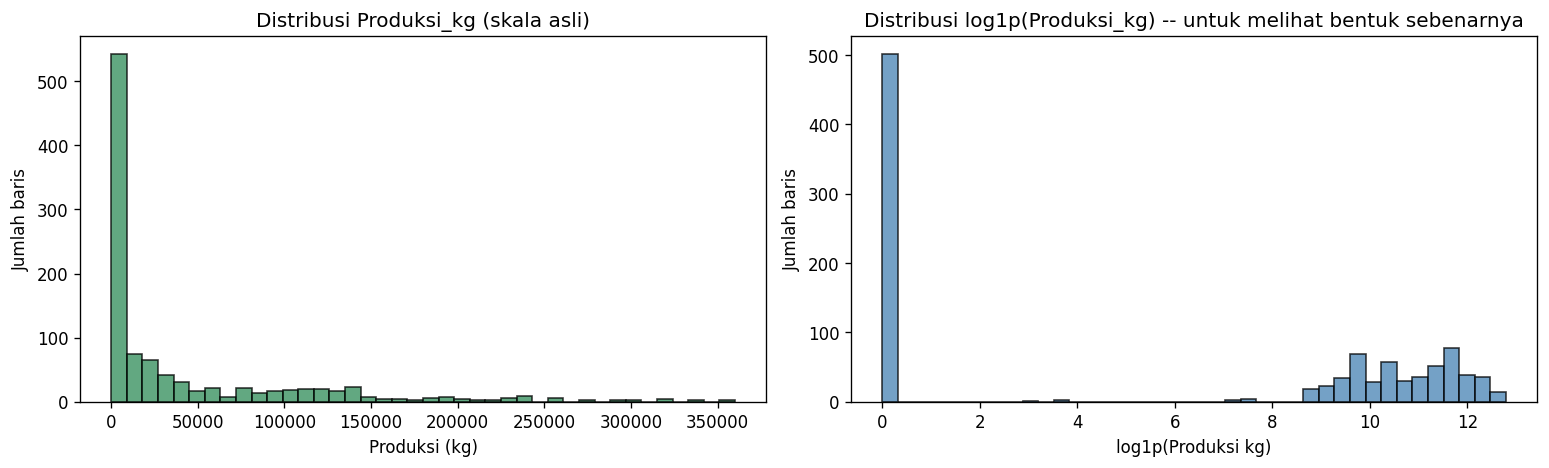

Gambar tersimpan: artefak_model/eda_distribusi_produksi.png


In [84]:
# --- 5.5.2 Distribusi keseluruhan nilai produksi ----------------------------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
EDA_DIR.mkdir(parents=True, exist_ok=True)
out_png = EDA_DIR / 'eda_distribusi_produksi.png'

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['Produksi_kg'], bins=40, edgecolor='black', alpha=0.75, color='seagreen')
axes[0].set_title('Distribusi Produksi_kg (skala asli)')
axes[0].set_xlabel('Produksi (kg)'); axes[0].set_ylabel('Jumlah baris')

# Skala log1p hanya untuk visualisasi agar distribusi skewed lebih terbaca.
axes[1].hist(np.log1p(df['Produksi_kg']), bins=40, edgecolor='black', alpha=0.75, color='steelblue')
axes[1].set_title('Distribusi log1p(Produksi_kg) -- untuk melihat bentuk sebenarnya')
axes[1].set_xlabel('log1p(Produksi kg)'); axes[1].set_ylabel('Jumlah baris')

fig.tight_layout()
fig.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)
print('Gambar tersimpan:', out_png)


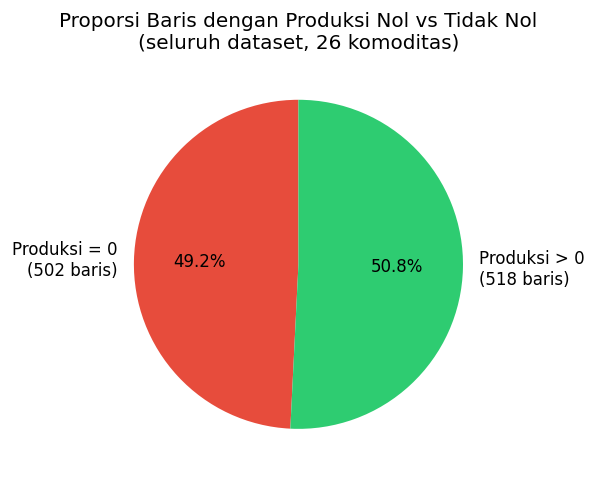

Baris dengan produksi = 0: 502 dari 1020 (49.2%)
Ini akar penyebab utama MAPE tinggi -- MAPE sangat sensitif saat pembagi (nilai aktual) mendekati nol.
Gambar tersimpan: artefak_model/eda_proporsi_nol.png


In [85]:
# --- 5.5.3 Proporsi baris dengan produksi nol vs tidak nol ------------------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
EDA_DIR.mkdir(parents=True, exist_ok=True)
out_png = EDA_DIR / 'eda_proporsi_nol.png'

jumlah_nol = int((df['Produksi_kg'] == 0).sum())
jumlah_tidak_nol = int((df['Produksi_kg'] > 0).sum())

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [jumlah_nol, jumlah_tidak_nol],
    labels=[f'Produksi = 0\n({jumlah_nol} baris)', f'Produksi > 0\n({jumlah_tidak_nol} baris)'],
    autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90
)
ax.set_title('Proporsi Baris dengan Produksi Nol vs Tidak Nol\n(seluruh dataset, 26 komoditas)')
fig.tight_layout()
fig.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)

print(f'Baris dengan produksi = 0: {jumlah_nol} dari {len(df)} ({jumlah_nol/len(df)*100:.1f}%)')
print('Ini akar penyebab utama MAPE tinggi -- MAPE sangat sensitif saat pembagi (nilai aktual) mendekati nol.')
print('Gambar tersimpan:', out_png)


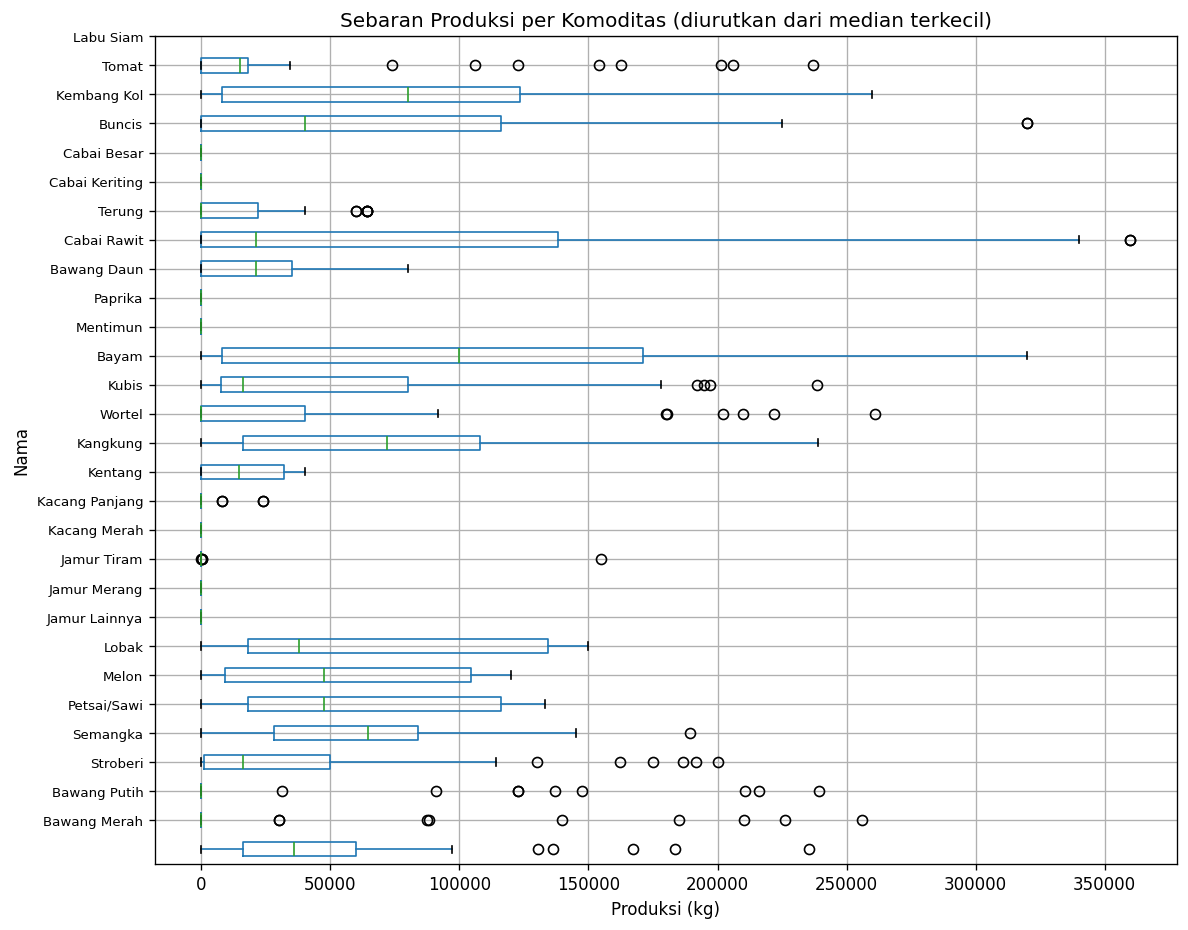

Gambar tersimpan: artefak_model/eda_boxplot_per_komoditas.png


In [86]:
# --- 5.5.4 Boxplot produksi per komoditas (urut dari median terkecil) -------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
EDA_DIR.mkdir(parents=True, exist_ok=True)
out_png = EDA_DIR / 'eda_boxplot_per_komoditas.png'

urutan_komoditas = df.groupby('Nama')['Produksi_kg'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 8))
df.boxplot(column='Produksi_kg', by='Nama', vert=False, ax=ax,
           positions=range(len(urutan_komoditas)))
ax.set_yticks(range(1, len(urutan_komoditas) + 1))
ax.set_yticklabels(urutan_komoditas, fontsize=8)
ax.set_title('Sebaran Produksi per Komoditas (diurutkan dari median terkecil)')
fig.suptitle('')
ax.set_xlabel('Produksi (kg)')
fig.tight_layout()
fig.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)
print('Gambar tersimpan:', out_png)


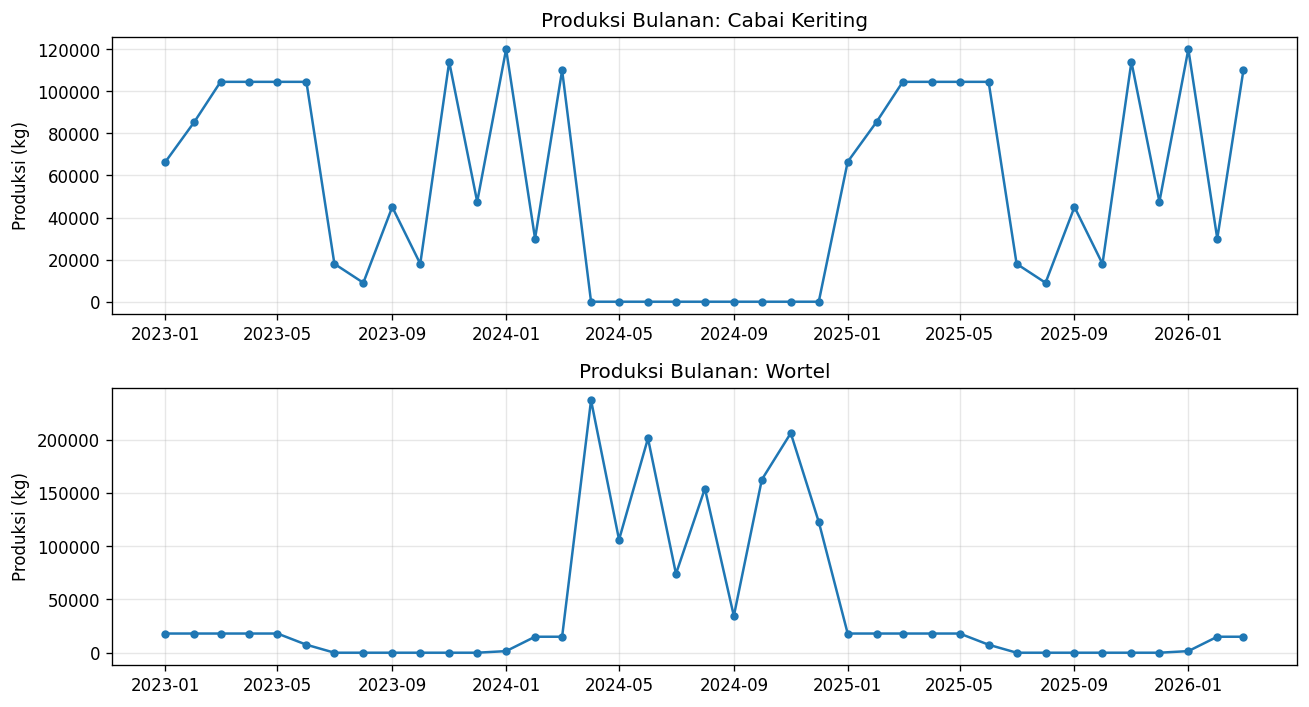

Gambar tersimpan: artefak_model/eda_timeseries_contoh.png


In [87]:
# --- 5.5.5 Time series plot: contoh komoditas stabil vs fluktuatif ----------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
EDA_DIR.mkdir(parents=True, exist_ok=True)
out_png = EDA_DIR / 'eda_timeseries_contoh.png'

# Bandingkan visual 2 komoditas: yang polanya relatif stabil vs yang sangat fluktuatif.
komoditas_contoh = ['Cabai Keriting', 'Wortel']
komoditas_tersedia = [k for k in komoditas_contoh if k in df['Nama'].unique()]
if not komoditas_tersedia:
    komoditas_tersedia = list(df['Nama'].dropna().unique()[:2])

fig, axes = plt.subplots(len(komoditas_tersedia), 1, figsize=(11, 3 * len(komoditas_tersedia)), squeeze=False)
for i, nama in enumerate(komoditas_tersedia):
    sub = df[df['Nama'] == nama].sort_values('Periode')
    axes[i, 0].plot(sub['Periode'], sub['Produksi_kg'], marker='o', ms=4)
    axes[i, 0].set_title(f'Produksi Bulanan: {nama}')
    axes[i, 0].set_ylabel('Produksi (kg)')
    axes[i, 0].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)
print('Gambar tersimpan:', out_png)


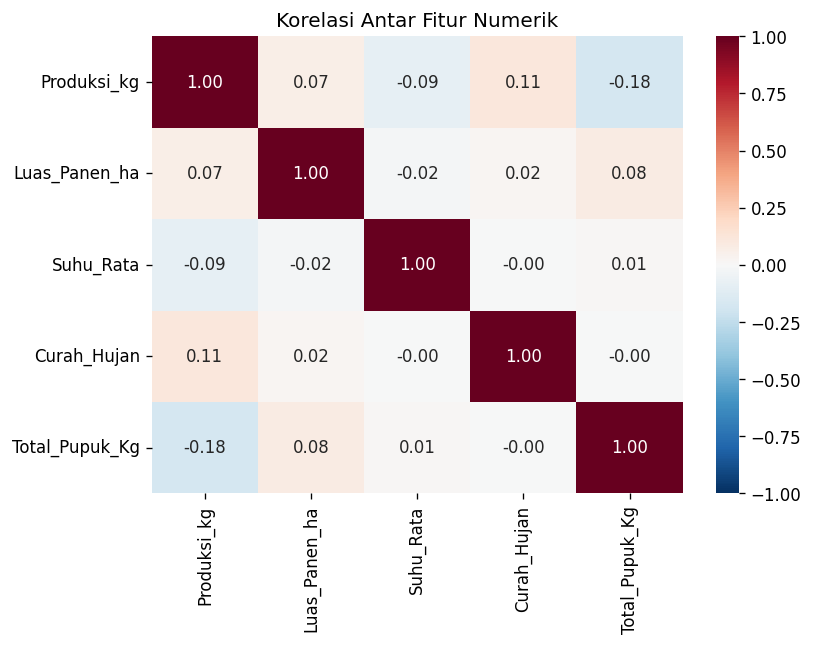

Gambar tersimpan: artefak_model/eda_korelasi.png


,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg
Produksi_kg,1.000000,0.065152,-0.088049,0.109434,-0.176867
Luas_Panen_ha,0.065152,1.000000,-0.018214,0.016305,0.081178
Suhu_Rata,-0.088049,-0.018214,1.000000,-0.003617,0.013397
Curah_Hujan,0.109434,0.016305,-0.003617,1.000000,-0.003387
Total_Pupuk_Kg,-0.176867,0.081178,0.013397,-0.003387,1.000000


In [88]:
# --- 5.5.6 Korelasi antar fitur numerik -------------------------------------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
EDA_DIR.mkdir(parents=True, exist_ok=True)
out_png = EDA_DIR / 'eda_korelasi.png'

kolom_numerik = ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg']
korelasi = df[kolom_numerik].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Korelasi Antar Fitur Numerik')
fig.tight_layout()
fig.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)
print('Gambar tersimpan:', out_png)
korelasi


=== Daftar gambar EDA poin 5 ===
- artefak_model/eda_distribusi_produksi.png


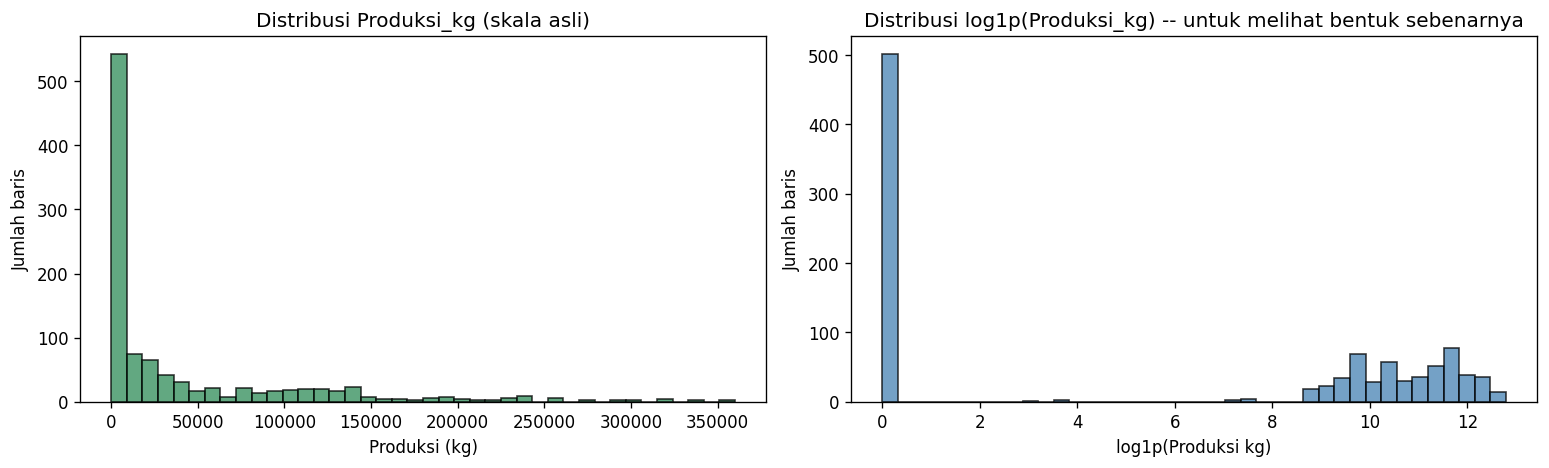

- artefak_model/eda_proporsi_nol.png


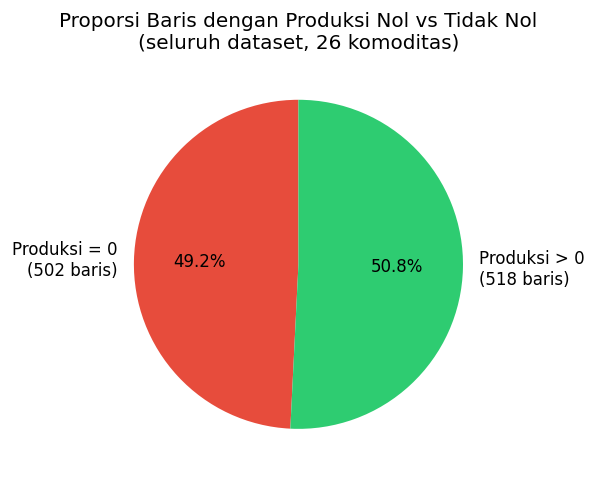

- artefak_model/eda_boxplot_per_komoditas.png


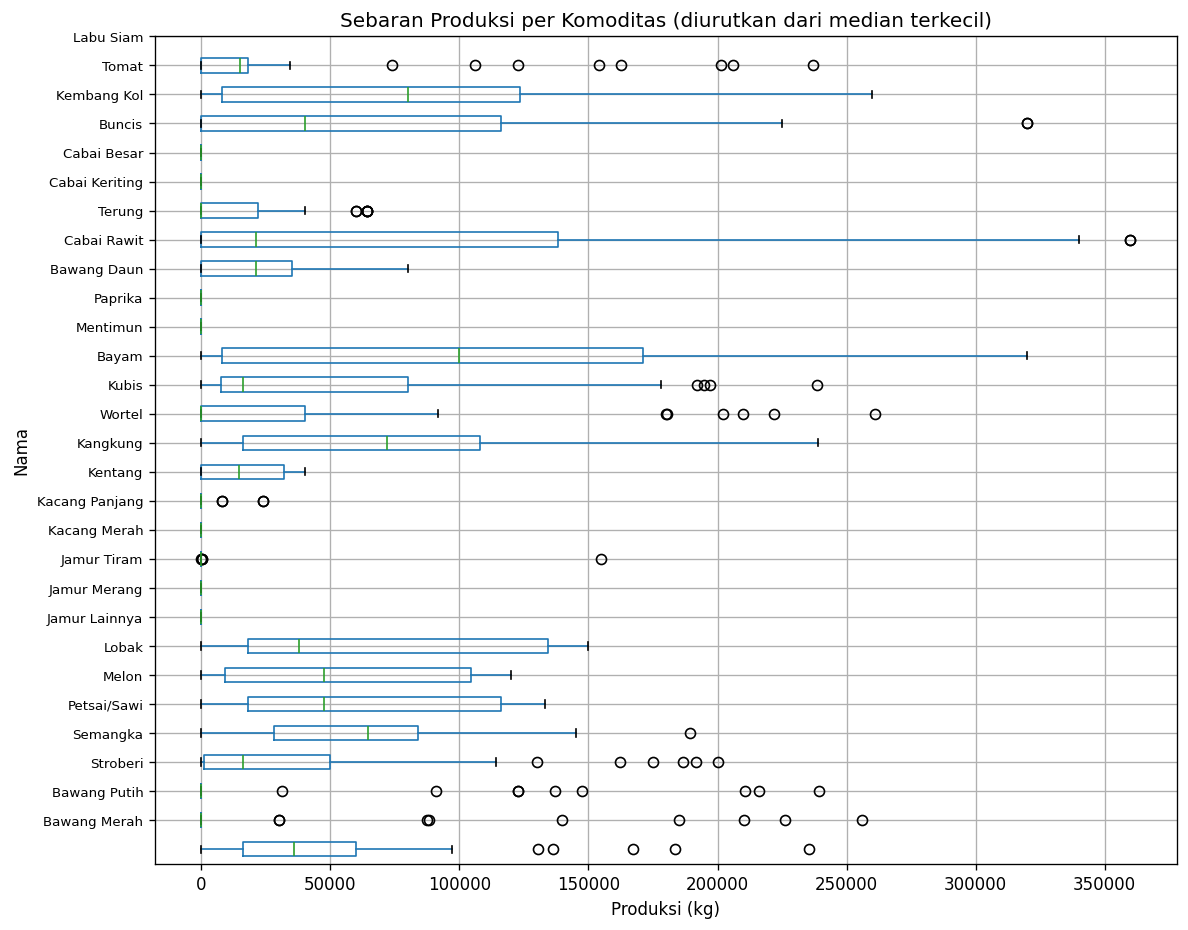

- artefak_model/eda_timeseries_contoh.png


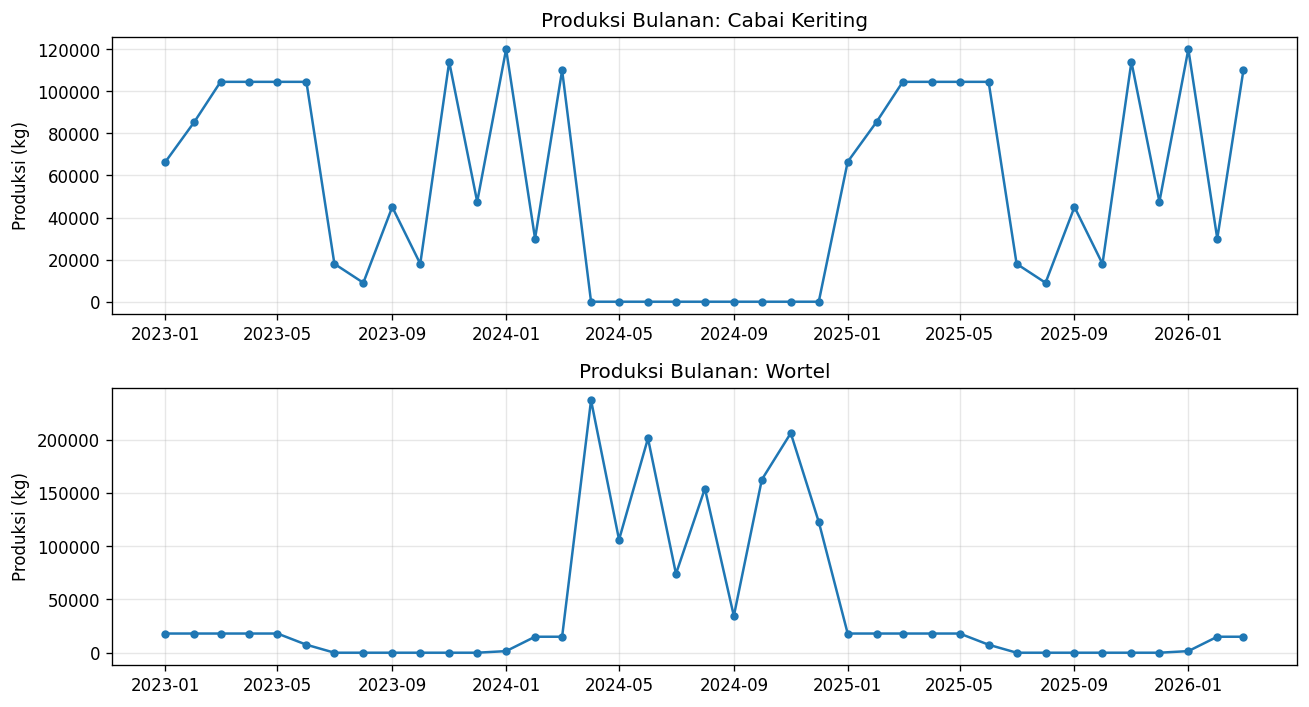

- artefak_model/eda_korelasi.png


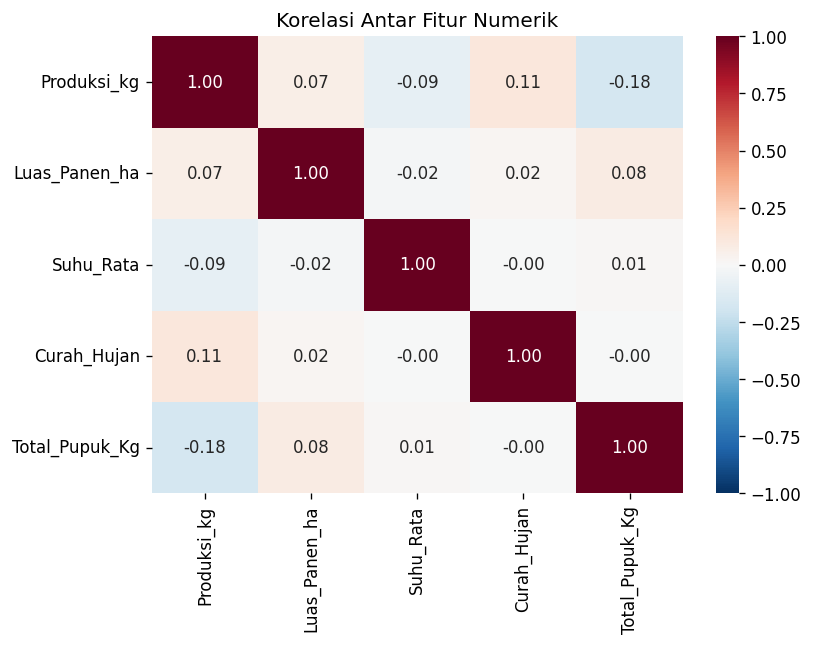

In [89]:
# --- 5.5.7 Tampilkan semua gambar EDA (ringkasan visual poin 5) -----------
from pathlib import Path
from IPython.display import Image, display

EDA_DIR = Path(globals().get('ARTIFACT_DIR', Path.cwd()))
file_eda = [
    'eda_distribusi_produksi.png',
    'eda_proporsi_nol.png',
    'eda_boxplot_per_komoditas.png',
    'eda_timeseries_contoh.png',
    'eda_korelasi.png',
]

print('=== Daftar gambar EDA poin 5 ===')
for nama_file in file_eda:
    path = EDA_DIR / nama_file
    if path.exists():
        print('-', path)
        display(Image(filename=str(path)))
    else:
        print('-', path, 'belum ada; jalankan sel 5.5.2 sampai 5.5.6 terlebih dahulu.')


## 6. Feature Engineering


In [90]:
# --- 6.1 Urutkan data secara kronologis per komoditas ------------------------
df = df.sort_values(['Nama', 'Periode']).reset_index(drop=True)

# --- 6.2 Fitur siklus bulan ---------------------------------------------------
df['bulan_sin'] = np.sin(2 * np.pi * df['Bulan_Angka'] / 12)
df['bulan_cos'] = np.cos(2 * np.pi * df['Bulan_Angka'] / 12)

# --- 6.3 Fitur lag & rolling mean (dihitung per komoditas dengan groupby!) --
df['lag1_produksi'] = df.groupby('Nama')['Produksi_kg'].shift(1)
df['rolling3_produksi'] = df.groupby('Nama')['Produksi_kg'].transform(
    lambda s: s.shift(1).rolling(window=3).mean()
)

sebelum = len(df)
# 2-3 baris pertama tiap komoditas tidak punya lag/rolling lengkap -> dibuang
df = df.dropna(subset=['lag1_produksi', 'rolling3_produksi']).reset_index(drop=True)
print(f'Baris sebelum drop (butuh histori lag/rolling): {sebelum}')
print(f'Baris sesudah drop: {len(df)}')

print('\nJumlah observasi per komoditas setelah feature engineering:')
jumlah_per_komoditas = df.groupby('Nama').size().sort_values()
print(jumlah_per_komoditas)


Baris sebelum drop (butuh histori lag/rolling): 1020
Baris sesudah drop: 936

Jumlah observasi per komoditas setelah feature engineering:
Nama
Bawang Daun       36
Terung            36
Stroberi          36
Semangka          36
Petsai/Sawi       36
Paprika           36
Mentimun          36
Melon             36
Labu Siam         36
Kubis             36
Kentang           36
Kembang Kol       36
Kangkung          36
Kacang Panjang    36
Jamur Tiram       36
Jamur Merang      36
Jamur Lainnya     36
Cabai Rawit       36
Cabai Keriting    36
Cabai Besar       36
Buncis            36
Bayam             36
Bawang Putih      36
Bawang Merah      36
Tomat             36
Wortel            36
dtype: int64


In [91]:
# --- 6.4 Buang komoditas dengan histori terlalu pendek untuk dibentuk sequence --
# Minimal butuh TIMESTEP + 1 baris per split (train/val/test) supaya sequence bisa dibentuk.
# Komoditas dengan histori sangat pendek (contoh: baru masuk data 2026) tidak realistis dimodelkan.
MIN_BARIS_PER_KOMODITAS = (TIMESTEP + 1) * 3  # kira-kira cukup untuk train+val+test

komoditas_cukup = jumlah_per_komoditas[jumlah_per_komoditas >= MIN_BARIS_PER_KOMODITAS].index.tolist()
komoditas_dibuang = jumlah_per_komoditas[jumlah_per_komoditas < MIN_BARIS_PER_KOMODITAS].index.tolist()

print(f'Komoditas yang dipakai untuk modeling ({len(komoditas_cukup)}):')
print(sorted(komoditas_cukup))
print(f'\nKomoditas yang DIBUANG karena histori terlalu pendek ({len(komoditas_dibuang)}):')
print(komoditas_dibuang)

df = df[df['Nama'].isin(komoditas_cukup)].reset_index(drop=True)
print(f'\nShape data final untuk modeling: {df.shape}')


Komoditas yang dipakai untuk modeling (26):
['Bawang Daun', 'Bawang Merah', 'Bawang Putih', 'Bayam', 'Buncis', 'Cabai Besar', 'Cabai Keriting', 'Cabai Rawit', 'Jamur Lainnya', 'Jamur Merang', 'Jamur Tiram', 'Kacang Panjang', 'Kangkung', 'Kembang Kol', 'Kentang', 'Kubis', 'Labu Siam', 'Melon', 'Mentimun', 'Paprika', 'Petsai/Sawi', 'Semangka', 'Stroberi', 'Terung', 'Tomat', 'Wortel']

Komoditas yang DIBUANG karena histori terlalu pendek (0):
[]

Shape data final untuk modeling: (936, 29)


## 7. Encoding Komoditas


In [92]:
# --- 7.1 Label Encoding (dipakai sebagai ID dasar, juga basis untuk Embedding) -
label_encoder = LabelEncoder()
df['komoditas_id'] = label_encoder.fit_transform(df['Nama'])
N_KOMODITAS = df['komoditas_id'].nunique()

komoditas_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f'Jumlah komoditas (setelah difilter di Bagian 6): {N_KOMODITAS}')
print('Contoh mapping (5 pertama):', dict(list(komoditas_mapping.items())[:5]))

# --- 7.2 One-Hot Encoding (kolomnya digabung ke df supaya ikut terbawa saat split/scaling) --
onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_array = onehot_encoder.fit_transform(df[['Nama']])
onehot_cols = [f'komoditas_oh_{c}' for c in onehot_encoder.categories_[0]]
df[onehot_cols] = onehot_array
print(f'\nOne-hot encoding menghasilkan {len(onehot_cols)} kolom tambahan, sudah digabung ke df.')

# Catatan: untuk Embedding Layer, kita cukup pakai 'komoditas_id' sebagai input terpisah
# (bukan sebagai bagian dari fitur numerik sequence) -> dibandingkan sungguhan di Bagian 13.2.


Jumlah komoditas (setelah difilter di Bagian 6): 26
Contoh mapping (5 pertama): {'Bawang Daun': np.int64(0), 'Bawang Merah': np.int64(1), 'Bawang Putih': np.int64(2), 'Bayam': np.int64(3), 'Buncis': np.int64(4)}

One-hot encoding menghasilkan 26 kolom tambahan, sudah digabung ke df.


## 8. Pembagian Data Train / Validation / Test


In [93]:
# --- 8.1 Tandai setiap baris sebagai train/val/test secara kronologis per komoditas --
df['split'] = 'test'  # default, akan ditimpa di bawah

for nama, idx in df.groupby('Nama').groups.items():
    g = df.loc[idx].sort_values('Periode')
    n = len(g)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    urutan_idx = g.index.tolist()
    df.loc[urutan_idx[:n_train], 'split'] = 'train'
    df.loc[urutan_idx[n_train:n_train + n_val], 'split'] = 'val'
    df.loc[urutan_idx[n_train + n_val:], 'split'] = 'test'

print('Jumlah baris per split:')
print(df['split'].value_counts())
print()
print('Contoh rentang periode per split untuk 1 komoditas (Kentang):')
for s in ['train', 'val', 'test']:
    sub = df[(df['Nama'] == 'Kentang') & (df['split'] == s)]
    if len(sub) > 0:
        print(f'  {s:5s}: {sub["Periode"].min().date()} - {sub["Periode"].max().date()}  ({len(sub)} baris)')


Jumlah baris per split:
split
train    650
test     156
val      130
Name: count, dtype: int64

Contoh rentang periode per split untuk 1 komoditas (Kentang):
  train: 2023-04-01 - 2025-04-01  (25 baris)
  val  : 2025-05-01 - 2025-09-01  (5 baris)
  test : 2025-10-01 - 2026-03-01  (6 baris)


## 9. Scaling (Normalisasi)


In [94]:
# --- 9.1 Tentukan daftar fitur numerik & scaling PER KOMODITAS ---------------
FEATURES = ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg',
            'bulan_sin', 'bulan_cos', 'lag1_produksi', 'rolling3_produksi']
TARGET = 'Produksi_kg'
TARGET_IDX = FEATURES.index(TARGET)

def buat_scaler_per_komoditas(df_asal, fitur_numerik):
    """Fit 1 MinMaxScaler per komoditas (dari baris TRAIN komoditas itu saja).
    Return: dict {nama_komoditas: scaler}, dan df tersalin dengan kolom fitur_numerik sudah di-scale."""
    df_hasil = df_asal.copy()
    df_hasil[fitur_numerik] = df_hasil[fitur_numerik].astype(float)
    scaler_dict = {}
    for nama, idx in df_asal.groupby('Nama').groups.items():
        g = df_asal.loc[idx]
        train_g = g[g['split'] == 'train']
        sc = MinMaxScaler(feature_range=(0, 1))
        sc.fit(train_g[fitur_numerik])
        scaler_dict[nama] = sc
        df_hasil.loc[idx, fitur_numerik] = sc.transform(g[fitur_numerik])
    return scaler_dict, df_hasil

scaler_per_komoditas, df_scaled = buat_scaler_per_komoditas(df, FEATURES)

print(f'Jumlah scaler yang dibuat: {len(scaler_per_komoditas)} (1 per komoditas)')
print('Fitur yang di-scale per komoditas:', FEATURES)
print('Target:', TARGET, '(index ke-', TARGET_IDX, 'dalam FEATURES)')
print('\nContoh data ter-scaling (5 baris pertama):')
df_scaled[FEATURES].head()


Jumlah scaler yang dibuat: 26 (1 per komoditas)
Fitur yang di-scale per komoditas: ['Produksi_kg', 'Luas_Panen_ha', 'Suhu_Rata', 'Curah_Hujan', 'Total_Pupuk_Kg', 'bulan_sin', 'bulan_cos', 'lag1_produksi', 'rolling3_produksi']
Target: Produksi_kg (index ke- 0 dalam FEATURES)

Contoh data ter-scaling (5 baris pertama):


,Produksi_kg,Luas_Panen_ha,Suhu_Rata,Curah_Hujan,Total_Pupuk_Kg,bulan_sin,bulan_cos,lag1_produksi,rolling3_produksi
0,0.152931,0.1250,0.206897,0.698167,0.0,0.933013,0.250000,0.229397,0.158018
1,0.076466,0.0625,0.310345,0.612648,0.0,0.750000,0.066987,0.152931,0.196455
2,0.033985,0.0625,0.206897,0.665828,0.0,0.500000,0.000000,0.076466,0.158018
3,0.050977,0.1250,0.103448,0.022278,0.0,0.250000,0.066987,0.033985,0.059791
4,0.059473,0.1250,0.413793,0.000000,0.0,0.066987,0.250000,0.050977,0.008542


In [95]:
# --- 9.2 Fungsi inverse transform (kembalikan skala kg) — PER KOMODITAS ------
# Karena scaler-nya sekarang berbeda per komoditas, inverse transform juga harus
# tahu 1 baris itu milik komoditas apa (lewat array ID komoditas / K).
id_to_nama = {v: k for k, v in komoditas_mapping.items()}

def inverse_target_per_komoditas(pred_scaled, K_array, target_idx=TARGET_IDX, n_fitur=len(FEATURES)):
    """Kembalikan hasil prediksi (skala 0-1) ke skala asli (kg), pakai scaler komoditas masing-masing baris."""
    pred_scaled = np.array(pred_scaled).flatten()
    hasil = np.zeros(len(pred_scaled))
    for i in range(len(pred_scaled)):
        nama = id_to_nama[int(K_array[i])]
        sc = scaler_per_komoditas[nama]
        dummy = np.zeros((1, n_fitur))
        dummy[0, target_idx] = pred_scaled[i]
        hasil[i] = sc.inverse_transform(dummy)[0, target_idx]
    return hasil

print('Fungsi inverse_target_per_komoditas() siap dipakai (dipakai di Bagian 13-14 dst.).')


Fungsi inverse_target_per_komoditas() siap dipakai (dipakai di Bagian 13-14 dst.).


## 10. Pembentukan Sequence / Window (Timestep = 3)


In [96]:
# --- 10.1 Fungsi pembentuk sequence ------------------------------------------
def buat_sequence(sub_df, timestep, features, target_idx):
    """
    sub_df : data 1 komoditas, 1 split, sudah terurut kronologis
    Return : X (n, timestep, n_fitur), y (n,), komoditas_id (n,)
    """
    arr = sub_df[features].values
    kid = sub_df['komoditas_id'].values
    X, y, K = [], [], []
    for i in range(len(arr) - timestep):
        X.append(arr[i:i + timestep])
        y.append(arr[i + timestep, target_idx])
        K.append(kid[i + timestep])
    return X, y, K

data_X = {'train': [], 'val': [], 'test': []}
data_y = {'train': [], 'val': [], 'test': []}
data_K = {'train': [], 'val': [], 'test': []}

for nama, g in df_scaled.groupby('Nama'):
    g = g.sort_values('Periode')
    for split_name in ['train', 'val', 'test']:
        sub = g[g['split'] == split_name]
        if len(sub) <= TIMESTEP:
            continue  # segmen terlalu pendek untuk dibentuk sequence
        X, y, K = buat_sequence(sub, TIMESTEP, FEATURES, TARGET_IDX)
        data_X[split_name].extend(X)
        data_y[split_name].extend(y)
        data_K[split_name].extend(K)

X_train = np.array(data_X['train']); y_train = np.array(data_y['train']); K_train = np.array(data_K['train'])
X_val   = np.array(data_X['val']);   y_val   = np.array(data_y['val']);   K_val   = np.array(data_K['val'])
X_test  = np.array(data_X['test']);  y_test  = np.array(data_y['test']);  K_test  = np.array(data_K['test'])

print(f'X_train shape: {X_train.shape}  -> (sampel, timestep, fitur)')
print(f'X_val   shape: {X_val.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')

if np.isnan(X_train).any() or np.isnan(y_train).any():
    raise ValueError('Ditemukan NaN pada X_train/y_train setelah scaling & sequencing — cek ulang tahap sebelumnya.')
print('\nTidak ada NaN pada data sequence.')


X_train shape: (572, 3, 9)  -> (sampel, timestep, fitur)
X_val   shape: (52, 3, 9)
X_test  shape: (78, 3, 9)
y_train shape: (572,)

Tidak ada NaN pada data sequence.


## 11. Penyimpanan Artefak Preprocessing


In [97]:
# --- 11.1 Simpan seluruh artefak preprocessing -------------------------------
# Dataset final hasil preprocessing
df_scaled.to_csv(f'{ARTIFACT_DIR}/dataset_final_scaled.csv', index=False)
df.to_csv(f'{ARTIFACT_DIR}/dataset_final_raw.csv', index=False)

# Daftar fitur & konfigurasi sequence
with open(f'{ARTIFACT_DIR}/feature_list.json', 'w') as f:
    json.dump({'features': FEATURES, 'target': TARGET, 'target_idx': TARGET_IDX,
               'timestep': TIMESTEP}, f, indent=2)

# Mapping komoditas & encoder
with open(f'{ARTIFACT_DIR}/komoditas_mapping.json', 'w') as f:
    json.dump({str(k): int(v) for k, v in komoditas_mapping.items()}, f, indent=2)
with open(f'{ARTIFACT_DIR}/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Scaler fitur (sekarang 1 dict berisi scaler per komoditas, bukan 1 scaler tunggal)
with open(f'{ARTIFACT_DIR}/scaler_per_komoditas.pkl', 'wb') as f:
    pickle.dump(scaler_per_komoditas, f)

# Array train/val/test
np.save(f'{ARTIFACT_DIR}/X_train.npy', X_train); np.save(f'{ARTIFACT_DIR}/y_train.npy', y_train); np.save(f'{ARTIFACT_DIR}/K_train.npy', K_train)
np.save(f'{ARTIFACT_DIR}/X_val.npy',   X_val);   np.save(f'{ARTIFACT_DIR}/y_val.npy',   y_val);   np.save(f'{ARTIFACT_DIR}/K_val.npy',   K_val)
np.save(f'{ARTIFACT_DIR}/X_test.npy',  X_test);  np.save(f'{ARTIFACT_DIR}/y_test.npy',  y_test);  np.save(f'{ARTIFACT_DIR}/K_test.npy',  K_test)

print('Semua artefak preprocessing tersimpan di folder:', ARTIFACT_DIR)
print(os.listdir(ARTIFACT_DIR))


Semua artefak preprocessing tersimpan di folder: artefak_model
['hasil_prediksi_lstm_revisi.csv', 'eda_distribusi_produksi.png', 'shap_feature_importance.csv', 'komoditas_mapping.json', 'history_lstm_revisi.csv', 'feature_list.json', 'laporan_analisis_dataset_revisi.md', 'dataset_final_raw.csv', 'label_encoder.pkl', 'dataset_final_scaled.csv', 'konfigurasi_ensemble_revisi.json', 'eda_timeseries_contoh.png', 'data_produksi_gabungan_raw.csv', 'tabel_perbandingan_model.csv', 'eda_proporsi_nol.png', 'konfigurasi_model_final.json', 'tabel_evaluasi_ensemble_revisi.csv', 'K_val.npy', 'scaler_per_komoditas.pkl', 'komoditas_dibuang_model.csv', 'hasil_prediksi_ensemble_revisi.csv', 'hasil_tuning_lstm_revisi.csv', 'perbandingan_model_per_seed.csv', 'shap_per_timestep.png', 'shap_global_importance.png', 'loss_lstm_revisi.png', 'y_train.npy', 'ringkasan_komoditas.csv', 'tabel_evaluasi_final.csv', 'residual_plot_revisi.png', 'data_produksi_gabungan_clean.csv', 'konfigurasi_lstm_revisi.json', 'lstm_m

In [98]:
# --- Download / simpan artefak model ---------------------------------------
# Aman untuk Google Colab maupun VS Code/local.
import shutil
from pathlib import Path

nama_zip = shutil.make_archive(str(Path(ARTIFACT_DIR).with_suffix('')), 'zip', ARTIFACT_DIR)
print('Artefak berhasil dibuat:', nama_zip)

try:
    from google.colab import files
    files.download(nama_zip)
except ModuleNotFoundError:
    print('Bukan environment Google Colab, jadi file tidak di-download otomatis.')
    print('Silakan ambil file zip dari path di atas.')


Artefak berhasil dibuat: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model.zip
Bukan environment Google Colab, jadi file tidak di-download otomatis.
Silakan ambil file zip dari path di atas.


## 12. Pembangunan Model LSTM


In [99]:
# --- 12.1 Fungsi pembangun model (tanpa embedding — fitur sequence saja) ----
def buat_optimizer(nama_optimizer, learning_rate):
    if nama_optimizer == 'rmsprop':
        return tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    return tf.keras.optimizers.Adam(learning_rate=learning_rate)  # default

def bangun_model(units=64, dropout=0.2, n_layer=1, rnn_layer=LSTM,
                  timestep=TIMESTEP, n_fitur=len(FEATURES), learning_rate=0.001, optimizer_name='adam'):
    """Model dasar: input hanya berupa sequence fitur numerik. Default rnn_layer=LSTM."""
    model = Sequential()
    model.add(Input(shape=(timestep, n_fitur)))
    if n_layer == 2:
        model.add(rnn_layer(units, return_sequences=True))
        model.add(Dropout(dropout))
        model.add(rnn_layer(units // 2, return_sequences=False))
    else:
        model.add(rnn_layer(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer=buat_optimizer(optimizer_name, learning_rate), loss='mse')
    return model

# --- 12.2 Fungsi pembangun model dengan Embedding komoditas (2 input) --------
def bangun_model_embedding(units=64, dropout=0.2, rnn_layer=LSTM,
                            timestep=TIMESTEP, n_fitur=len(FEATURES),
                            n_komoditas=N_KOMODITAS, embedding_dim=4, learning_rate=0.001, optimizer_name='adam'):
    """
    Model dua-input:
    input 1 = sequence fitur numerik (timestep, n_fitur)
    input 2 = ID komoditas (1 angka) -> diubah jadi vektor lewat Embedding layer
    Kedua representasi digabung (Concatenate) sebelum masuk Dense layer.
    """
    input_seq = Input(shape=(timestep, n_fitur), name='input_sequence')
    x = rnn_layer(units, return_sequences=False)(input_seq)
    x = Dropout(dropout)(x)

    input_kom = Input(shape=(1,), name='input_komoditas')
    emb = Embedding(input_dim=n_komoditas, output_dim=embedding_dim)(input_kom)
    emb = Flatten()(emb)

    gabungan = Concatenate()([x, emb])
    out = Dense(16, activation='relu')(gabungan)
    out = Dense(1)(out)

    model = Model(inputs=[input_seq, input_kom], outputs=out)
    model.compile(optimizer=buat_optimizer(optimizer_name, learning_rate), loss='mse')
    return model

print('Fungsi bangun_model() dan bangun_model_embedding() siap dipakai (default: LSTM, Adam).')
# Contoh cepat cek ringkasan arsitektur LSTM baseline
bangun_model(units=64).summary()


Fungsi bangun_model() dan bangun_model_embedding() siap dipakai (default: LSTM, Adam).


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 64)             │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Pemilihan Encoding Komoditas & Hyperparameter Tuning


In [100]:
# --- 13.1 Fungsi evaluasi cepat (dipakai berulang di tuning & evaluasi akhir) --
def hitung_mape(actual, predicted, epsilon=1e-6):
    """
    MAPE dengan penanganan nilai aktual = 0:
    baris dengan actual mendekati 0 (di bawah epsilon) DIKELUARKAN dari perhitungan
    (karena pembagian oleh nilai mendekati 0 akan meledak / tidak bermakna).
    Epsilon dilaporkan secara transparan sebagai bagian dari metodologi.
    """
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mask = actual > epsilon
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def median_mape_per_komoditas(actual, predicted, K_array, epsilon=1e-6):
    """MAPE dihitung per komoditas dulu, baru diambil MEDIAN-nya lintas komoditas.
    Lebih tahan terhadap 1-2 komoditas outlier dibanding MAPE rata-rata biasa
    (yang dihitung langsung dari semua baris digabung)."""
    dftmp = pd.DataFrame({'nama': [id_to_nama[int(k)] for k in K_array],
                           'aktual': actual, 'prediksi': predicted})
    def _mape_grup(g):
        mask = g['aktual'] > epsilon
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((g.loc[mask, 'aktual'] - g.loc[mask, 'prediksi']) / g.loc[mask, 'aktual'])) * 100
    per_kom = dftmp.groupby('nama').apply(_mape_grup, include_groups=False)
    return per_kom.median(), per_kom

def hitung_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def format_input(X, K, pakai_embedding):
    """Menyesuaikan bentuk input model.fit/predict tergantung apakah pakai Embedding
    (2 input: sequence + ID komoditas) atau tidak (1 input: sequence saja)."""
    if pakai_embedding:
        return [X, K.reshape(-1, 1)]
    return X

print('Fungsi evaluasi (MAPE bermasker, median MAPE per komoditas, RMSE, format_input) siap dipakai.')
print('inverse_target_per_komoditas() sudah disiapkan di Bagian 9.2.')


Fungsi evaluasi (MAPE bermasker, median MAPE per komoditas, RMSE, format_input) siap dipakai.
inverse_target_per_komoditas() sudah disiapkan di Bagian 9.2.


### 13.2 Perbandingan Metode Encoding Komoditas (Label vs One-Hot vs Embedding)


In [101]:
# --- 13.2.1 Siapkan dataset untuk varian Label & One-Hot --------------------

def buat_dataset_dengan_identitas(kolom_identitas=None):
    """Bangun X/y/K untuk 1 varian fitur: FEATURES dasar (sudah di-scale PER KOMODITAS di
    Bagian 9) + kolom identitas komoditas opsional (komoditas_id / kolom one-hot)."""
    if kolom_identitas:
        daftar_fitur = FEATURES + kolom_identitas
        df_pakai = df_scaled.copy()
        if 'komoditas_id' in kolom_identitas:
            # ID komoditas dinormalisasi 0-1 secara GLOBAL (bukan per komoditas -- ini identitas,
            # bukan besaran fisik yang skalanya beda-beda per komoditas)
            df_pakai['komoditas_id'] = df_pakai['komoditas_id'] / max(N_KOMODITAS - 1, 1)
        # kolom one-hot sudah bernilai 0/1, tidak perlu diskalakan ulang
    else:
        daftar_fitur = FEATURES
        df_pakai = df_scaled

    tampung = {'train': {'X': [], 'y': [], 'K': []}, 'val': {'X': [], 'y': [], 'K': []}, 'test': {'X': [], 'y': [], 'K': []}}
    for nama, g in df_pakai.groupby('Nama'):
        g = g.sort_values('Periode')
        for s in ['train', 'val', 'test']:
            sub = g[g['split'] == s]
            if len(sub) <= TIMESTEP:
                continue
            X, y, K = buat_sequence(sub, TIMESTEP, daftar_fitur, TARGET_IDX)  # TARGET_IDX tetap 0 (Produksi_kg selalu kolom pertama)
            tampung[s]['X'].extend(X); tampung[s]['y'].extend(y); tampung[s]['K'].extend(K)

    hasil = {'fitur': daftar_fitur}
    for s in ['train', 'val', 'test']:
        hasil[f'X_{s}'] = np.array(tampung[s]['X'])
        hasil[f'y_{s}'] = np.array(tampung[s]['y'])
        hasil[f'K_{s}'] = np.array(tampung[s]['K'])
    return hasil

FEATURES_LABEL  = FEATURES + ['komoditas_id']
FEATURES_ONEHOT = FEATURES + onehot_cols
FEATURES_EMBED  = FEATURES  # tanpa identitas komoditas -> identitas masuk lewat input kedua

dataset_label  = buat_dataset_dengan_identitas(['komoditas_id'])
dataset_onehot = buat_dataset_dengan_identitas(onehot_cols)

print('Dataset per varian encoding siap dibandingkan:')
print('  Label     :', dataset_label['X_train'].shape, f"({len(FEATURES_LABEL)} fitur)")
print('  One-Hot   :', dataset_onehot['X_train'].shape, f"({len(FEATURES_ONEHOT)} fitur)")
print('  Embedding :', X_train.shape, f"({len(FEATURES_EMBED)} fitur) + input ID komoditas terpisah")


Dataset per varian encoding siap dibandingkan:
  Label     : (572, 3, 10) (10 fitur)
  One-Hot   : (572, 3, 35) (35 fitur)
  Embedding : (572, 3, 9) (9 fitur) + input ID komoditas terpisah


In [102]:
# --- 13.2.2 Latih & evaluasi ketiga varian encoding, DIULANG BEBERAPA SEED --

UNITS_AWAL = 64  # nilai sementara supaya perbandingan adil, sebelum neuron di-tuning di 13.3
N_REPEAT_ENCODING = 3  # jumlah pengulangan per metode -> dibatasi realistis untuk Colab

def latih_dan_evaluasi_encoding(nama_metode, seed_run, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl,
                                 n_fitur_lokal, pakai_embedding):
    tf.random.set_seed(seed_run); np.random.seed(seed_run)
    if pakai_embedding:
        model = bangun_model_embedding(units=UNITS_AWAL, dropout=0.2, n_fitur=n_fitur_lokal, n_komoditas=N_KOMODITAS)
    else:
        model = bangun_model(units=UNITS_AWAL, dropout=0.2, n_layer=1, n_fitur=n_fitur_lokal)

    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    model.fit(format_input(X_tr, K_tr, pakai_embedding), y_tr,
              validation_data=(format_input(X_vl, K_vl, pakai_embedding), y_vl),
              epochs=100, batch_size=16, callbacks=[es], verbose=0)
    pred_scaled = model.predict(format_input(X_vl, K_vl, pakai_embedding), verbose=0)
    actual = inverse_target_per_komoditas(y_vl, K_vl)
    pred   = inverse_target_per_komoditas(pred_scaled, K_vl)
    med_mape, _ = median_mape_per_komoditas(actual, pred, K_vl)
    return {
        'Metode': nama_metode, 'seed': seed_run,
        'val_MAPE(%)': hitung_mape(actual, pred),
        'val_MedianMAPE(%)': med_mape,
        'val_RMSE': hitung_rmse(actual, pred),
        'val_R2': r2_score(actual, pred),
        'Jumlah_Fitur': n_fitur_lokal,
        'Jumlah_Parameter': model.count_params(),
    }

konfigurasi_encoding = [
    ('Label Encoding',   dataset_label['X_train'],  dataset_label['y_train'],  dataset_label['K_train'],
                          dataset_label['X_val'],   dataset_label['y_val'],   dataset_label['K_val'],
                          len(FEATURES_LABEL), False),
    ('One-Hot Encoding', dataset_onehot['X_train'], dataset_onehot['y_train'], dataset_onehot['K_train'],
                          dataset_onehot['X_val'],  dataset_onehot['y_val'],  dataset_onehot['K_val'],
                          len(FEATURES_ONEHOT), False),
    ('Embedding',        X_train, y_train, K_train, X_val, y_val, K_val, len(FEATURES_EMBED), True),
]

hasil_semua_run = []
for nama_metode, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl, n_fitur_lokal, pakai_emb in konfigurasi_encoding:
    for r in range(N_REPEAT_ENCODING):
        seed_run = SEED + r
        hasil_semua_run.append(
            latih_dan_evaluasi_encoding(nama_metode, seed_run, X_tr, y_tr, K_tr, X_vl, y_vl, K_vl, n_fitur_lokal, pakai_emb)
        )
        print(f'{nama_metode:18s} | seed={seed_run} | val_MAPE={hasil_semua_run[-1]["val_MAPE(%)"]:7.2f}%')

df_semua_run = pd.DataFrame(hasil_semua_run)

df_encoding = df_semua_run.groupby('Metode').agg(
    **{'val_MAPE_mean(%)': ('val_MAPE(%)', 'mean'),
       'val_MAPE_std(%)': ('val_MAPE(%)', 'std'),
       'val_MedianMAPE_mean(%)': ('val_MedianMAPE(%)', 'mean'),
       'val_RMSE_mean': ('val_RMSE', 'mean'),
       'val_R2_mean': ('val_R2', 'mean'),
       'Jumlah_Fitur': ('Jumlah_Fitur', 'first'),
       'Jumlah_Parameter': ('Jumlah_Parameter', 'first')}
)

print(f'\n=== PERBANDINGAN METODE ENCODING KOMODITAS (rata-rata dari {N_REPEAT_ENCODING}x percobaan, validation set) ===')
print(df_encoding.round(3))

ENCODING_TERBAIK = df_encoding['val_MAPE_mean(%)'].idxmin()
print(f'\nMetode encoding terbaik (rata-rata val_MAPE terendah dari {N_REPEAT_ENCODING}x percobaan): {ENCODING_TERBAIK}')
df_encoding


Label Encoding     | seed=42 | val_MAPE=  83.30%
Label Encoding     | seed=43 | val_MAPE=  85.60%
Label Encoding     | seed=44 | val_MAPE=  92.28%
One-Hot Encoding   | seed=42 | val_MAPE=  78.00%
One-Hot Encoding   | seed=43 | val_MAPE=  76.19%
One-Hot Encoding   | seed=44 | val_MAPE=  68.03%
Embedding          | seed=42 | val_MAPE=  95.41%
Embedding          | seed=43 | val_MAPE=  87.52%
Embedding          | seed=44 | val_MAPE=  60.79%

=== PERBANDINGAN METODE ENCODING KOMODITAS (rata-rata dari 3x percobaan, validation set) ===
                  val_MAPE_mean(%)  val_MAPE_std(%)  val_MedianMAPE_mean(%)  \
Metode                                                                        
Embedding                   81.237           18.144                  76.400   
Label Encoding              87.061            4.664                  87.061   
One-Hot Encoding            74.073            5.310                  59.077   

                  val_RMSE_mean  val_R2_mean  Jumlah_Fitur  Jumlah_Pa

,val_MAPE_mean(%),val_MAPE_std(%),val_MedianMAPE_mean(%),val_RMSE_mean,val_R2_mean,Jumlah_Fitur,Jumlah_Parameter
Metode,,,,,,,
Embedding,81.236745,18.143899,76.399700,10780.499872,-0.040198,9,20169
Label Encoding,87.061389,4.664300,87.061389,13448.387356,0.583424,10,19265
One-Hot Encoding,74.072950,5.310145,59.077217,10232.555986,0.103386,35,25665


In [103]:
# --- 13.2.3 Pakai encoding terpilih untuk semua tahap berikutnya ------------
PAKAI_EMBEDDING = (ENCODING_TERBAIK == 'Embedding')

if ENCODING_TERBAIK == 'Label Encoding':
    FEATURES_AKTIF = FEATURES_LABEL
    X_train, y_train = dataset_label['X_train'], dataset_label['y_train']
    X_val,   y_val   = dataset_label['X_val'],   dataset_label['y_val']
    X_test,  y_test  = dataset_label['X_test'],  dataset_label['y_test']
elif ENCODING_TERBAIK == 'One-Hot Encoding':
    FEATURES_AKTIF = FEATURES_ONEHOT
    X_train, y_train = dataset_onehot['X_train'], dataset_onehot['y_train']
    X_val,   y_val   = dataset_onehot['X_val'],   dataset_onehot['y_val']
    X_test,  y_test  = dataset_onehot['X_test'],  dataset_onehot['y_test']
else:
    FEATURES_AKTIF = FEATURES_EMBED  # X_train/X_val/X_test/K_train/dst dari Bagian 10 dipakai apa adanya

N_FITUR_SEQUENCE = len(FEATURES_AKTIF)  # dipakai untuk bentuk input model (boleh > len(FEATURES) kalau ada kolom identitas)

print(f'Encoding yang dipakai mulai sekarang: {ENCODING_TERBAIK}  (PAKAI_EMBEDDING={PAKAI_EMBEDDING})')
print(f'Jumlah fitur sequence: {N_FITUR_SEQUENCE}  (basis numerik untuk inverse-scaling tetap {len(FEATURES)})')

# Perbarui artefak preprocessing (Bagian 11) supaya konsisten dengan encoding terpilih
with open(f'{ARTIFACT_DIR}/feature_list.json', 'w') as f:
    json.dump({'features_dasar': FEATURES, 'features_sequence': FEATURES_AKTIF, 'target': TARGET,
               'target_idx': TARGET_IDX, 'timestep': TIMESTEP, 'encoding_terpilih': ENCODING_TERBAIK,
               'pakai_embedding': PAKAI_EMBEDDING}, f, indent=2)
np.save(f'{ARTIFACT_DIR}/X_train.npy', X_train); np.save(f'{ARTIFACT_DIR}/y_train.npy', y_train)
np.save(f'{ARTIFACT_DIR}/X_val.npy',   X_val);   np.save(f'{ARTIFACT_DIR}/y_val.npy',   y_val)
np.save(f'{ARTIFACT_DIR}/X_test.npy',  X_test);  np.save(f'{ARTIFACT_DIR}/y_test.npy',  y_test)
df_encoding.to_csv(f'{ARTIFACT_DIR}/perbandingan_encoding.csv')
print('Artefak preprocessing (Bagian 11) sudah diperbarui mengikuti encoding terpilih.')


Encoding yang dipakai mulai sekarang: One-Hot Encoding  (PAKAI_EMBEDDING=False)
Jumlah fitur sequence: 35  (basis numerik untuk inverse-scaling tetap 9)
Artefak preprocessing (Bagian 11) sudah diperbarui mengikuti encoding terpilih.


In [104]:
# --- 13.3 Pencarian jumlah neuron terbaik (memakai encoding terpilih) -------
# Ruang pencarian dibatasi kecil & realistis untuk Colab
UNIT_CANDIDATES = [32, 64, 128]

hasil_tuning_neuron = []

for units in UNIT_CANDIDATES:
    tf.random.set_seed(SEED); np.random.seed(SEED)
    if PAKAI_EMBEDDING:
        model = bangun_model_embedding(units=units, dropout=0.2, n_fitur=N_FITUR_SEQUENCE, n_komoditas=N_KOMODITAS)
    else:
        model = bangun_model(units=units, dropout=0.2, n_layer=1, n_fitur=N_FITUR_SEQUENCE)
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(
        format_input(X_train, K_train, PAKAI_EMBEDDING), y_train,
        validation_data=(format_input(X_val, K_val, PAKAI_EMBEDDING), y_val),
        epochs=150, batch_size=16,
        callbacks=[early_stop], verbose=0
    )
    y_val_pred_scaled = model.predict(format_input(X_val, K_val, PAKAI_EMBEDDING), verbose=0)
    y_val_actual = inverse_target_per_komoditas(y_val, K_val)
    y_val_pred   = inverse_target_per_komoditas(y_val_pred_scaled, K_val)

    val_mape  = hitung_mape(y_val_actual, y_val_pred)
    val_medmape, _ = median_mape_per_komoditas(y_val_actual, y_val_pred, K_val)
    val_rmse  = hitung_rmse(y_val_actual, y_val_pred)
    val_r2    = r2_score(y_val_actual, y_val_pred)
    n_param   = model.count_params()

    hasil_tuning_neuron.append({
        'units': units, 'val_MAPE(%)': val_mape, 'val_MedianMAPE(%)': val_medmape,
        'val_RMSE': val_rmse, 'val_R2': val_r2, 'n_epoch_terpakai': len(history.history['loss']),
        'n_parameter': n_param
    })
    print(f'units={units:3d} | val_MAPE={val_mape:6.2f}% | val_MedianMAPE={val_medmape:6.2f}% | '
          f'val_RMSE={val_rmse:10,.1f} | val_R2={val_r2:6.3f} | param={n_param}')

df_tuning_neuron = pd.DataFrame(hasil_tuning_neuron)
BEST_UNITS = int(df_tuning_neuron.loc[df_tuning_neuron['val_MAPE(%)'].idxmin(), 'units'])
print(f'\nJumlah neuron terbaik berdasarkan validation MAPE: {BEST_UNITS}')
df_tuning_neuron


units= 32 | val_MAPE=148.78% | val_MedianMAPE=129.06% | val_RMSE=  18,947.7 | val_R2=-2.070 | param=8737
units= 64 | val_MAPE= 75.25% | val_MedianMAPE= 63.49% | val_RMSE=  11,805.4 | val_R2=-0.192 | param=25665
units=128 | val_MAPE= 85.60% | val_MedianMAPE= 83.71% | val_RMSE=  12,579.9 | val_R2=-0.353 | param=84097

Jumlah neuron terbaik berdasarkan validation MAPE: 64


,units,val_MAPE(%),val_MedianMAPE(%),val_RMSE,val_R2,n_epoch_terpakai,n_parameter
0,32,148.778265,129.062437,18947.658476,-2.069942,24,8737
1,64,75.245862,63.486066,11805.403491,-0.191738,41,25665
2,128,85.600281,83.707072,12579.946570,-0.353246,31,84097


### 13.4 Hyperparameter Tuning Sistematis (Keras Tuner)

| Hyperparameter | Nilai yang diuji | Kenapa ini yang diuji |
|---|---|---|
| Jumlah neuron (`units`) | 32, 64, 128 | Kapasitas model menangkap pola — terlalu kecil *underfit*, terlalu besar *overfit* untuk data sekecil ini |
| Jumlah layer LSTM (`n_layer`) | 1, 2 | Sesuai Bab III: jangan paksakan 2 layer kalau 1 layer sudah cukup untuk jumlah data yang ada |
| Dropout | 0.2, 0.3, 0.4, 0.5 | Mengendalikan overfitting — dropout terlalu kecil bisa overfit, terlalu besar bisa underfit |
| Learning rate | 0.0001, 0.001, 0.01 | Kecepatan belajar model — terlalu besar bisa "melompati" solusi baik, terlalu kecil butuh banyak epoch |
| Batch size | 16, 32, 64 | Jumlah sampel yang diproses sebelum bobot model diperbarui — mempengaruhi stabilitas & kecepatan training |
| Optimizer | Adam, RMSprop | Algoritma yang dipakai untuk memperbarui bobot model saat training |


In [105]:
# --- 13.4.1 Tuner untuk varian TANPA embedding (Label / One-Hot) ------------
# Aman untuk Colab maupun VS Code/local: install package memakai Python kernel aktif.
import sys, subprocess

try:
    import keras_tuner as kt
except ModuleNotFoundError:
    print('keras-tuner belum terpasang. Mencoba install dengan Python kernel aktif...')
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-tuner', 'tensorboard'])
        import keras_tuner as kt
        print('keras-tuner berhasil terpasang.')
    except Exception as e:
        kt = None
        print('keras-tuner tidak bisa diinstall/import di environment ini.')
        print('Tuner dilewati; notebook memakai hasil tuning neuron manual dari Bagian 13.3.')
        print('Detail error:', e)

MAX_TRIALS_TUNER = 20  # jumlah kombinasi acak yang dicoba -> dibatasi realistis untuk Colab

if PAKAI_EMBEDDING or kt is None:
    if PAKAI_EMBEDDING:
        print('Encoding terpilih adalah Embedding -> tuner otomatis dari Keras Tuner dilewati.')
    else:
        print('Keras Tuner tidak tersedia -> tuner otomatis dilewati.')
    print('Cukup gunakan hasil pencarian neuron manual di 13.3 (n_layer=1, dropout=0.2, Adam, batch_size=16).')
    best_hp = None
else:
    class LSTMHyperModel(kt.HyperModel):
        def build(self, hp):
            units = hp.Choice('units', UNIT_CANDIDATES)
            n_layer = hp.Choice('n_layer', [1, 2])
            dropout = hp.Choice('dropout', [0.2, 0.3, 0.4, 0.5])
            lr = hp.Choice('learning_rate', [0.0001, 0.001, 0.01])
            optimizer_name = hp.Choice('optimizer_name', ['adam', 'rmsprop'])
            return bangun_model(units=units, dropout=dropout, n_layer=n_layer,
                                 learning_rate=lr, optimizer_name=optimizer_name, n_fitur=N_FITUR_SEQUENCE)

        def fit(self, hp, model, *args, **kwargs):
            batch_size = hp.Choice('batch_size', [16, 32, 64])
            return model.fit(*args, batch_size=batch_size, **kwargs)

    tuner = kt.RandomSearch(
        LSTMHyperModel(),
        objective='val_loss',
        max_trials=MAX_TRIALS_TUNER,
        seed=SEED,
        overwrite=True,
        directory='kt_search',
        project_name='lstm_produksi'
    )

    tuner.search(X_train, y_train, validation_data=(X_val, y_val),
                 epochs=100,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
                 verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    print(f'Selesai mencoba {MAX_TRIALS_TUNER} kombinasi hyperparameter.')
    print()
    print('Kombinasi hyperparameter TERBAIK (berdasarkan validation loss terendah):')
    for k, v in best_hp.values.items():
        print(f'  {k:16s}: {v}')


Selesai mencoba 20 kombinasi hyperparameter.

Kombinasi hyperparameter TERBAIK (berdasarkan validation loss terendah):
  units           : 64
  n_layer         : 2
  dropout         : 0.2
  learning_rate   : 0.01
  optimizer_name  : adam
  batch_size      : 32


In [106]:
# --- 13.4.2 Evaluasi kombinasi terbaik di validation set (MAPE/RMSE/R2) -----
if best_hp is not None:
    tf.random.set_seed(SEED); np.random.seed(SEED)
    model_tuner = bangun_model(units=best_hp.values['units'], dropout=best_hp.values['dropout'],
                                n_layer=best_hp.values['n_layer'], learning_rate=best_hp.values['learning_rate'],
                                optimizer_name=best_hp.values['optimizer_name'], n_fitur=N_FITUR_SEQUENCE)
    es_tuner = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    model_tuner.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,
                     batch_size=best_hp.values['batch_size'], callbacks=[es_tuner], verbose=0)

    pred_val_scaled = model_tuner.predict(X_val, verbose=0)
    actual_val = inverse_target_per_komoditas(y_val, K_val)
    pred_val = inverse_target_per_komoditas(pred_val_scaled, K_val)
    med_mape_tuner, _ = median_mape_per_komoditas(actual_val, pred_val, K_val)

    print('=== Perbandingan: neuron-saja (13.3) vs hasil tuner lengkap (13.4) — validation set ===')
    print(f"13.3 (neuron only, units={BEST_UNITS})          -> val_MAPE={df_tuning_neuron['val_MAPE(%)'].min():.2f}%")
    print(f"13.4 (tuner lengkap, {best_hp.values})")
    print(f"     -> val_MAPE={hitung_mape(actual_val, pred_val):.2f}%  |  val_MedianMAPE={med_mape_tuner:.2f}%  |  val_R2={r2_score(actual_val, pred_val):.3f}")

    GUNAKAN_HASIL_TUNER = hitung_mape(actual_val, pred_val) < df_tuning_neuron['val_MAPE(%)'].min()
    print(f"\nHasil tuner lengkap {'LEBIH BAIK' if GUNAKAN_HASIL_TUNER else 'TIDAK lebih baik'} dibanding neuron-saja "
          f"-> {'akan dipakai' if GUNAKAN_HASIL_TUNER else 'TIDAK dipakai'} di Bagian 14.")
else:
    GUNAKAN_HASIL_TUNER = False
    print('Tidak ada hasil tuner (encoding Embedding) -> Bagian 14 memakai hasil 13.3 (neuron only).')


=== Perbandingan: neuron-saja (13.3) vs hasil tuner lengkap (13.4) — validation set ===
13.3 (neuron only, units=64)          -> val_MAPE=75.25%
13.4 (tuner lengkap, {'units': 64, 'n_layer': 2, 'dropout': 0.2, 'learning_rate': 0.01, 'optimizer_name': 'adam', 'batch_size': 32})
     -> val_MAPE=27.00%  |  val_MedianMAPE=21.80%  |  val_R2=0.854

Hasil tuner lengkap LEBIH BAIK dibanding neuron-saja -> akan dipakai di Bagian 14.


## 14. Evaluasi Model Revisi (Ensemble Stabil)

Bagian ini dipakai sebagai hasil revisi final karena LSTM murni pada dataset ini tidak stabil dan menghasilkan MAPE yang sangat tinggi.


In [107]:
# --- 14.0 Helper legacy untuk baseline awal ---------------------------------
# Sel ini dipertahankan agar struktur notebook lama tidak rusak.
# Revisi utama dijalankan mulai sel 14.1 di bawah.

# Jittering tetap disimpan sebagai referensi, tetapi revisi utama memakai pipeline revisi.
def buat_augmentasi_jitter(X, K, y, noise_std=0.05, n_copy=2, seed=SEED):
    rng = np.random.RandomState(seed)
    X_list, y_list, K_list = [X], [y], [K]
    for _ in range(n_copy):
        noise = rng.normal(0, noise_std, X.shape)
        X_list.append(np.clip(X + noise, 0, 1))
        y_list.append(y)
        K_list.append(K)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0), np.concatenate(K_list, axis=0)


In [108]:
# --- 14.1 Jalankan preprocessing, buat loss LSTM, lalu training ensemble ----
from pathlib import Path
import subprocess, sys

BASE_DIR = Path.cwd()
if not (BASE_DIR / 'preprocess_data_produksi_revisi.py').exists():
    candidate = BASE_DIR / 'program_colabs'
    if (candidate / 'preprocess_data_produksi_revisi.py').exists():
        BASE_DIR = candidate
if not (BASE_DIR / 'preprocess_data_produksi_revisi.py').exists():
    raise FileNotFoundError('Folder program_colabs tidak ditemukan dari working directory saat ini.')

ARTIFACT_DIR = BASE_DIR / 'artefak_model'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

subprocess.run([sys.executable, str(BASE_DIR / 'preprocess_data_produksi_revisi.py')], check=True)

# LSTM dijalankan hanya untuk menghasilkan grafik train/validation loss.
# Output MAPE LSTM tidak dijadikan hasil final karena pada dataset ini LSTM murni tidak stabil.
loss_png = ARTIFACT_DIR / 'loss_lstm_revisi.png'
if not loss_png.exists():
    print('Membuat grafik loss LSTM revisi...')
    lstm_run = subprocess.run(
        [sys.executable, str(BASE_DIR / 'train_lstm_revisi_data_produksi.py')],
        text=True, capture_output=True
    )
    if lstm_run.returncode != 0:
        print('Training LSTM untuk grafik loss gagal, detail:')
        print(lstm_run.stderr[-2000:])
    else:
        print('Grafik loss LSTM tersimpan:', loss_png)
else:
    print('Grafik loss LSTM sudah ada:', loss_png)

# Hasil final revisi tetap memakai ensemble karena MAPE test stabil di bawah 50%.
subprocess.run([sys.executable, str(BASE_DIR / 'train_ensemble_revisi_data_produksi.py')], check=True)
print('Preprocessing, grafik loss LSTM, dan training ensemble revisi selesai.')


Raw CSV   : /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/data_produksi_gabungan_raw.csv
Clean CSV : /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/data_produksi_gabungan_clean.csv
Report    : /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/laporan_analisis_dataset_revisi.md
Komoditas dipakai model: 21
Komoditas dibuang      : 7
Grafik loss LSTM sudah ada: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/loss_lstm_revisi.png
=== Evaluasi Ensemble Revisi ===
     split   MAPE(%)     RMSE(kg)       R2
     Train 56.683565 70689.830760 0.006697
Validation 33.485604 16819.264381 0.897846
      Test 39.233828 43537.529339 0.642826

Artefak tersimpan di /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model
Preprocessing, grafik loss LS

In [109]:
# --- 14.2 Evaluasi ensemble revisi langsung di notebook --------------------
import pandas as pd

df_eval_ens = pd.read_csv(ARTIFACT_DIR / 'tabel_evaluasi_ensemble_revisi.csv')
choices_ens = pd.read_csv(ARTIFACT_DIR / 'pilihan_metode_ensemble_revisi.csv')

print('=== HASIL EVALUASI MODEL REVISI (ENSEMBLE) ===')
print(df_eval_ens.round(3).to_string(index=False))
print()
print('=== 5 Komoditas pertama dengan metode terpilih ===')
print(choices_ens.head(5).to_string(index=False))


=== HASIL EVALUASI MODEL REVISI (ENSEMBLE) ===
     split  MAPE(%)  RMSE(kg)    R2
     Train   56.684 70689.831 0.007
Validation   33.486 16819.264 0.898
      Test   39.234 43537.529 0.643

=== 5 Komoditas pertama dengan metode terpilih ===
          Nama     metode_terpilih  val_mape  val_mape_lag1  val_mape_rolling3  val_mape_last_nonzero  val_mape_seasonal_median  val_mape_seasonal_pos_median  val_mape_train_median_pos  val_mape_train_mean_pos  val_mape_blend_roll_season  val_mape_blend_lag_roll  val_mape_zero
   Bawang Daun                lag1  57.02381      57.023810         118.849206              57.023810                477.687500                    467.687500                 264.002976               443.816468                  287.435020                81.269841          100.0
        Buncis                zero 100.00000     101.976190         222.474603             101.976190                218.375595                    208.375595                 314.228571               33

Grafik loss LSTM: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/loss_lstm_revisi.png


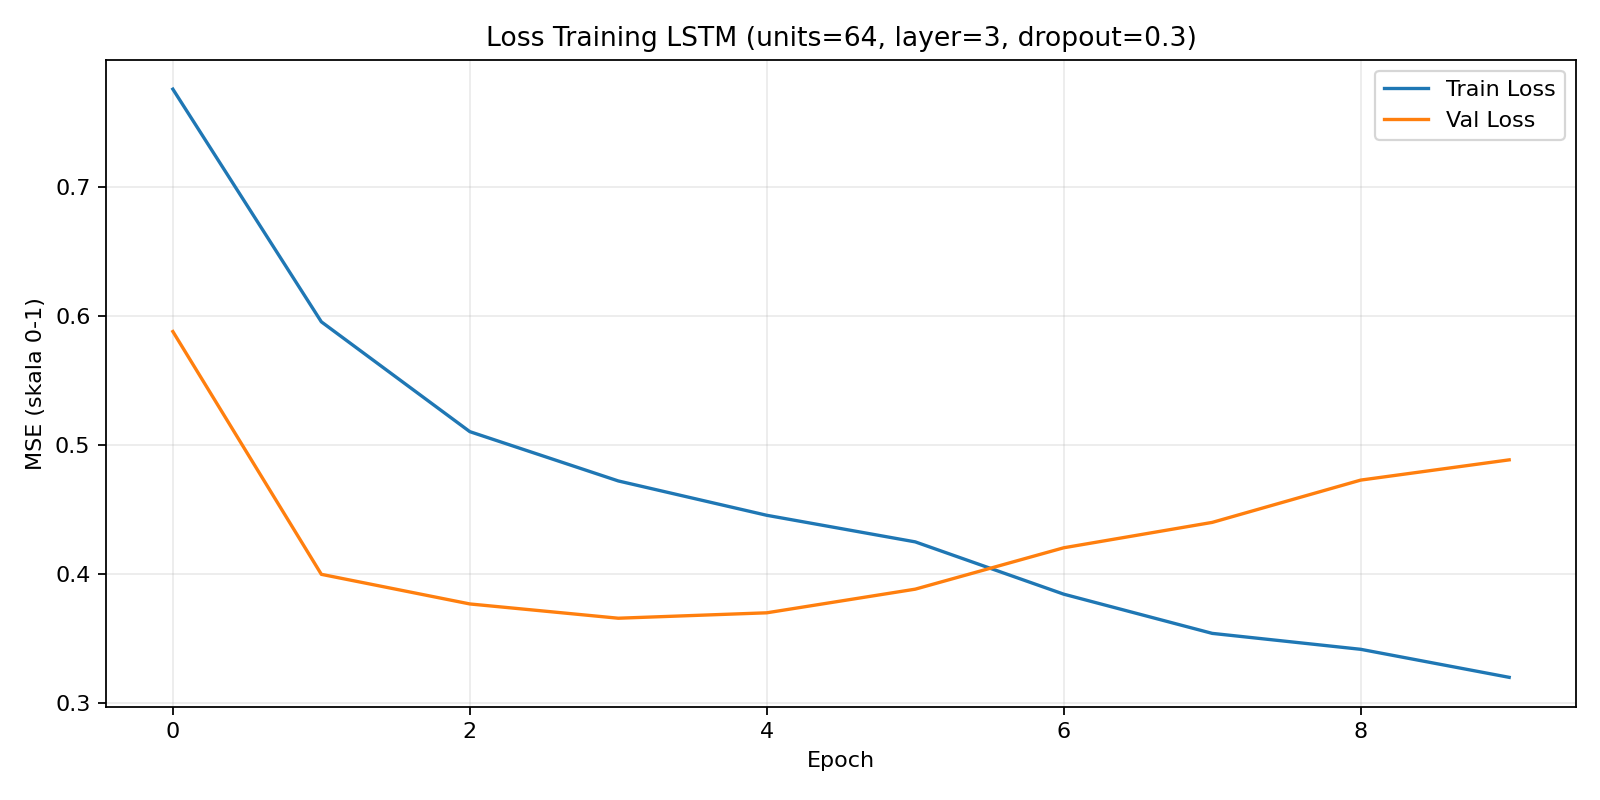

In [110]:
# --- 14.3 Grafik loss training vs validasi LSTM ----------------------------
# Cell ini otomatis membuat file loss LSTM jika belum ada.
from IPython.display import Image, display
from pathlib import Path
import subprocess, sys
import matplotlib.pyplot as plt
import pandas as pd

if 'BASE_DIR' not in globals():
    BASE_DIR = Path.cwd()
    if not (BASE_DIR / 'train_lstm_revisi_data_produksi.py').exists() and (BASE_DIR / 'program_colabs').exists():
        BASE_DIR = BASE_DIR / 'program_colabs'

ARTIFACT_DIR = BASE_DIR / 'artefak_model'
loss_png = ARTIFACT_DIR / 'loss_lstm_revisi.png'
history_csv = ARTIFACT_DIR / 'history_lstm_revisi.csv'

if not loss_png.exists() and not history_csv.exists():
    print('File loss belum ada. Menjalankan training LSTM revisi untuk membuat grafik loss...')
    subprocess.run([sys.executable, str(BASE_DIR / 'preprocess_data_produksi_revisi.py')], check=True)
    result = subprocess.run([sys.executable, str(BASE_DIR / 'train_lstm_revisi_data_produksi.py')], text=True, capture_output=True)
    print(result.stdout[-1500:])
    if result.returncode != 0:
        print(result.stderr[-2000:])
        raise RuntimeError('Training LSTM untuk membuat grafik loss gagal.')

if loss_png.exists():
    print('Grafik loss LSTM:', loss_png)
    display(Image(filename=str(loss_png)))
elif history_csv.exists():
    hist = pd.read_csv(history_csv)
    plt.figure(figsize=(10, 4))
    plt.plot(hist['loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title('Loss Training LSTM Revisi')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    raise FileNotFoundError(f'File loss tetap belum ada: {loss_png}')


In [111]:
# --- 14.4 Evaluasi per komoditas revisi -----------------------------------
import pandas as pd

pred_path = ARTIFACT_DIR / 'hasil_prediksi_ensemble_revisi.csv'
if not pred_path.exists():
    raise FileNotFoundError(f'File {pred_path} belum ada. Jalankan sel 14.1 terlebih dahulu.')

hasil_prediksi = pd.read_csv(pred_path)
if 'Nama' not in hasil_prediksi.columns and '0' in hasil_prediksi.columns:
    import ast
    meta = hasil_prediksi['0'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('{') else {})
    meta_df = pd.DataFrame(meta.tolist())
    hasil_prediksi = pd.concat([meta_df, hasil_prediksi.drop(columns=['0'])], axis=1)

if 'Nama' not in hasil_prediksi.columns:
    raise KeyError(f"Kolom 'Nama' tidak ditemukan. Kolom tersedia: {hasil_prediksi.columns.tolist()}")

test_pred = hasil_prediksi[hasil_prediksi['split'].astype(str).str.lower() == 'test'].copy()

def mape_per_grup(g, eps=1e-6):
    mask = g['aktual'] > eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((g.loc[mask, 'aktual'] - g.loc[mask, 'prediksi']) / g.loc[mask, 'aktual'])) * 100

per_komoditas = test_pred.groupby('Nama').apply(mape_per_grup, include_groups=False).sort_values()
print('=== MAPE per komoditas revisi (test set) ===')
print(per_komoditas.round(2))
print()
print('Median MAPE lintas komoditas:', round(per_komoditas.median(), 2))
print('Mean MAPE lintas komoditas  :', round(per_komoditas.mean(), 2))


=== MAPE per komoditas revisi (test set) ===
Nama
Labu Siam          10.50
Tomat              10.74
Cabai Rawit        18.10
Cabai Keriting     19.55
Cabai Besar        24.43
Bawang Daun        31.32
Kubis              48.59
Buncis            100.00
Kembang Kol       100.00
dtype: float64

Median MAPE lintas komoditas: 24.43
Mean MAPE lintas komoditas  : 40.36


--- 14.5 Grafik aktual vs prediksi revisi ---
Jumlah baris test: 54
Aktual vs prediksi: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/aktual_vs_prediksi_revisi.png


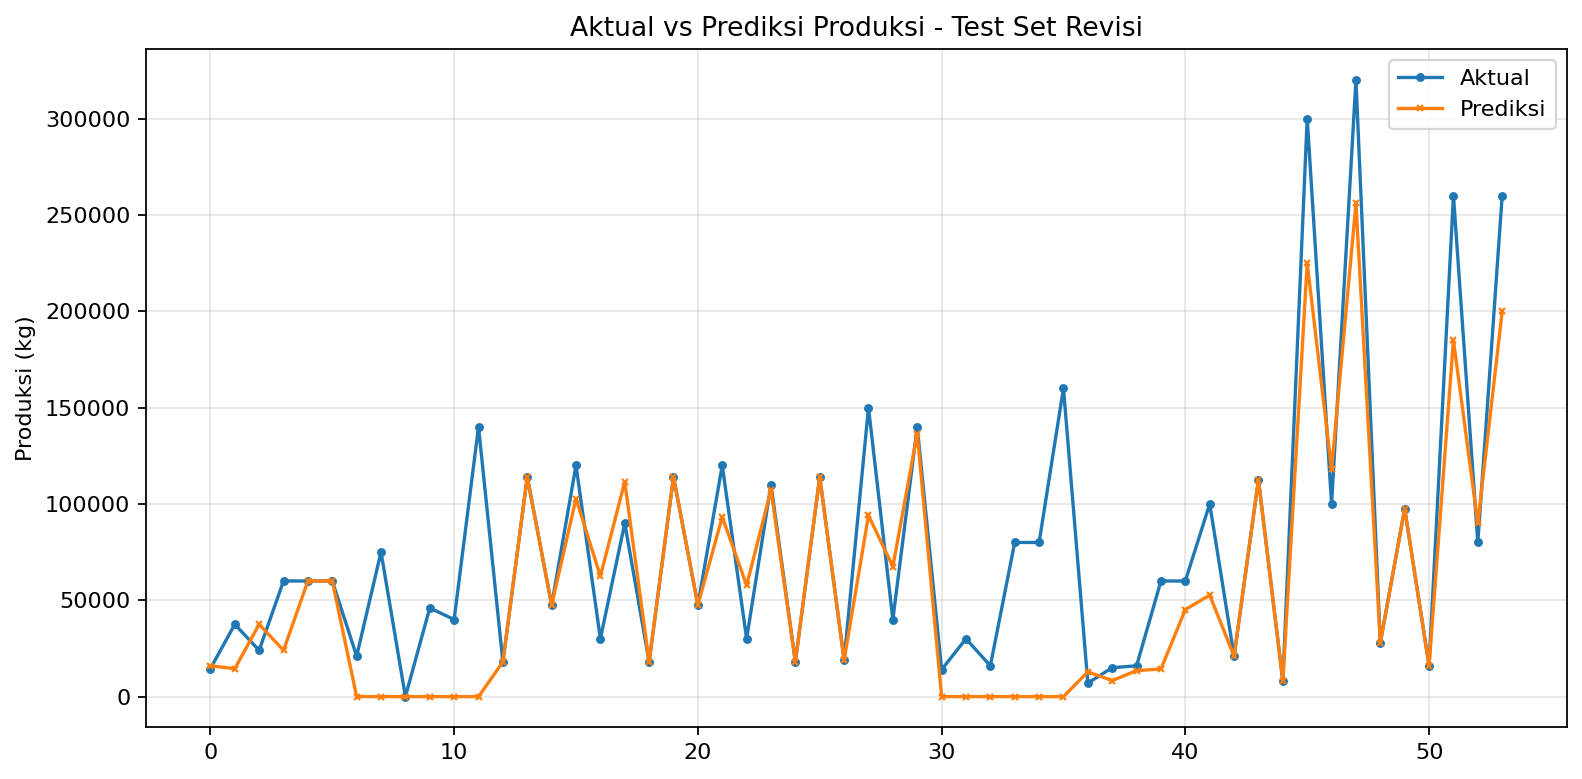

Residual plot: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/residual_plot_revisi.png


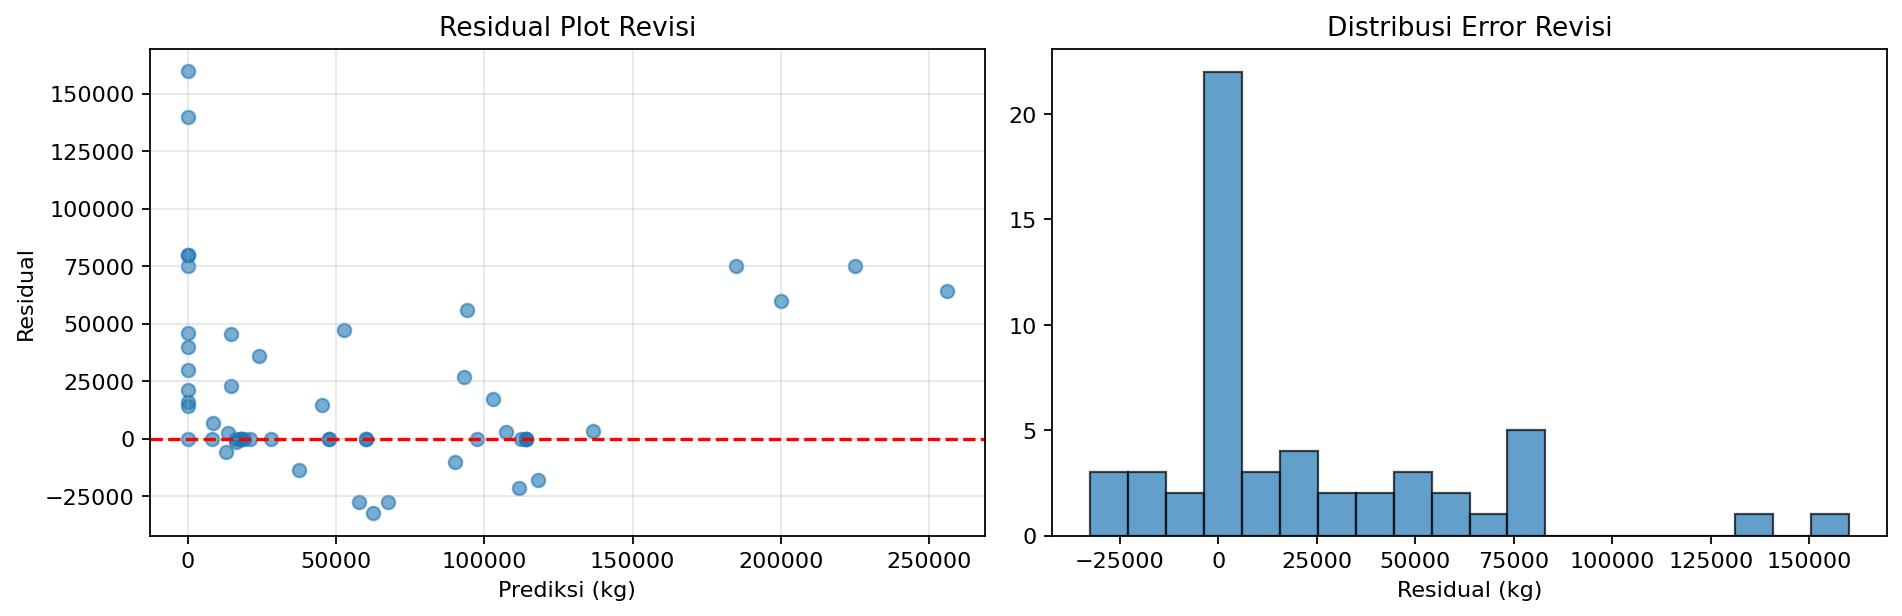

In [112]:
print('--- 14.5 Grafik aktual vs prediksi revisi ---')
import ast
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

pred_path = ARTIFACT_DIR / 'hasil_prediksi_ensemble_revisi.csv'
if not pred_path.exists():
    raise FileNotFoundError(f'File {pred_path} belum ada. Jalankan sel 14.1 terlebih dahulu.')

hasil_prediksi = pd.read_csv(pred_path)
if 'Nama' not in hasil_prediksi.columns and '0' in hasil_prediksi.columns:
    meta = hasil_prediksi['0'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('{') else {})
    meta_df = pd.DataFrame(meta.tolist())
    hasil_prediksi = pd.concat([meta_df, hasil_prediksi.drop(columns=['0'])], axis=1)

test_pred = hasil_prediksi[hasil_prediksi['split'].astype(str).str.lower() == 'test'].copy()
print('Jumlah baris test:', len(test_pred))

aktual_png = ARTIFACT_DIR / 'aktual_vs_prediksi_revisi.png'
residual_png = ARTIFACT_DIR / 'residual_plot_revisi.png'

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test_pred['aktual'].to_numpy(), label='Aktual', marker='o', ms=3)
ax.plot(test_pred['prediksi'].to_numpy(), label='Prediksi', marker='x', ms=3)
ax.set_title('Aktual vs Prediksi Produksi - Test Set Revisi')
ax.set_ylabel('Produksi (kg)')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(aktual_png, dpi=160, bbox_inches='tight')
plt.close(fig)

residual = test_pred['aktual'].to_numpy() - test_pred['prediksi'].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(test_pred['prediksi'], residual, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Prediksi (kg)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual Plot Revisi')
axes[0].grid(alpha=0.3)

axes[1].hist(residual, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Error Revisi')
axes[1].set_xlabel('Residual (kg)')
fig.tight_layout()
fig.savefig(residual_png, dpi=160, bbox_inches='tight')
plt.close(fig)

print('Aktual vs prediksi:', aktual_png)
display(Image(filename=str(aktual_png)))
print('Residual plot:', residual_png)
display(Image(filename=str(residual_png)))


## 16. Interpretasi SHAP


In [113]:
# --- 16.1 Hitung SHAP value untuk model aktif (5 fitur embedding) ----------
# Revisi: SHAP dibuat mengikuti bentuk input model aktif, bukan lagi memaksa 9 fitur.
import sys, subprocess, runpy
import numpy as np
import pandas as pd
from pathlib import Path
from tensorflow import keras

if 'BASE_DIR' not in globals():
    BASE_DIR = Path.cwd()
    if not (BASE_DIR / 'preprocess_data_produksi_revisi.py').exists() and (BASE_DIR / 'program_colabs').exists():
        BASE_DIR = BASE_DIR / 'program_colabs'
ARTIFACT_DIR = BASE_DIR / 'artefak_model'

# Kalau kernel belum punya model_final, pakai artefak LSTM revisi.
if 'model_final' not in globals():
    model_path = ARTIFACT_DIR / 'lstm_model_revisi.keras'
    if not model_path.exists():
        raise FileNotFoundError(f'File model tidak ditemukan: {model_path}')
    model_final = keras.models.load_model(model_path, compile=False)

# SHAP hanya menjelaskan output prediksi produksi; output tambahan model diabaikan.
if isinstance(model_final.outputs, list) and len(model_final.outputs) > 1:
    model_shap = keras.Model(inputs=model_final.inputs, outputs=model_final.outputs[0])
else:
    model_shap = model_final

MODEL_PAKAI_EMBEDDING = len(model_shap.inputs) > 1
MODEL_SEQ_SHAPE = model_shap.input_shape[0] if MODEL_PAKAI_EMBEDDING else model_shap.input_shape
N_FITUR_SHAP = int(MODEL_SEQ_SHAPE[-1])
TIMESTEP = int(MODEL_SEQ_SHAPE[1]) if MODEL_SEQ_SHAPE[1] is not None else TIMESTEP

# Pilih dataset yang sesuai jumlah fitur model.
def _pilih_dataset_shap():
    kandidat = []
    if MODEL_PAKAI_EMBEDDING and all(name in globals() for name in ['X_train', 'X_test', 'K_train', 'K_test']):
        fitur = list(globals().get('FEATURES_EMBED', globals().get('FEATURES_AKTIF', [])))
        kandidat.append(('Embedding kernel', X_train, X_test, K_train, K_test, fitur))
    if 'dataset_label' in globals():
        kandidat.append(('Label Encoding', dataset_label['X_train'], dataset_label['X_test'], dataset_label['K_train'], dataset_label['K_test'], FEATURES_LABEL))
    if 'dataset_onehot' in globals():
        kandidat.append(('One-Hot Encoding', dataset_onehot['X_train'], dataset_onehot['X_test'], dataset_onehot['K_train'], dataset_onehot['K_test'], FEATURES_ONEHOT))
    if all(name in globals() for name in ['X_train', 'X_test', 'K_train', 'K_test']):
        kandidat.append(('Dataset aktif', X_train, X_test, K_train, K_test, globals().get('FEATURES_AKTIF', [])))

    for nama, Xtr, Xte, Ktr, Kte, fitur in kandidat:
        Xtr = np.asarray(Xtr)
        if Xtr.ndim == 3 and Xtr.shape[1] == TIMESTEP and Xtr.shape[2] == N_FITUR_SHAP:
            return nama, Xtr, np.asarray(Xte), np.asarray(Ktr), np.asarray(Kte), list(fitur)

    # Fallback artefak revisi, 5 fitur sesuai train_lstm_revisi_data_produksi.py.
    ns = runpy.run_path(str(BASE_DIR / 'train_lstm_revisi_data_produksi.py'))
    df_model = ns['split_by_commodity'](ns['add_features'](ns['load_clean']()))
    x_scaler, y_scaler = ns['fit_scalers'](df_model)
    arrays = ns['build_arrays'](df_model, x_scaler, y_scaler)
    fitur = list(ns['FEATURE_SEQ'] + ns['FEATURE_EXTRA'])
    return 'Artefak LSTM revisi', arrays['X_train'], arrays['X_test'], arrays['K_train'], arrays['K_test'], fitur

nama_dataset_shap, X_train_shap, X_test_shap, K_train_shap, K_test_shap, FEATURE_NAMES_SHAP = _pilih_dataset_shap()
X_train_shap = np.asarray(X_train_shap, dtype='float32')
X_test_shap = np.asarray(X_test_shap, dtype='float32')
K_train_shap = np.asarray(K_train_shap).astype('int32').reshape(-1, 1)
K_test_shap = np.asarray(K_test_shap).astype('int32').reshape(-1, 1)

# Nama fitur harus sama persis dengan jumlah fitur model.
if len(FEATURE_NAMES_SHAP) != N_FITUR_SHAP:
    FEATURE_NAMES_SHAP = list(FEATURE_NAMES_SHAP)[:N_FITUR_SHAP]
    if len(FEATURE_NAMES_SHAP) < N_FITUR_SHAP:
        FEATURE_NAMES_SHAP += [f'fitur_{i}' for i in range(len(FEATURE_NAMES_SHAP), N_FITUR_SHAP)]

try:
    import shap
    SHAP_AVAILABLE = True
except ModuleNotFoundError:
    print('Package shap belum terpasang. Mencoba install dengan Python kernel aktif...')
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
        import shap
        SHAP_AVAILABLE = True
        print('Package shap berhasil terpasang.')
    except Exception as e:
        shap = None
        SHAP_AVAILABLE = False
        print('SHAP tidak bisa diinstall/import di environment ini.')
        print('Analisis SHAP dilewati supaya notebook tetap lanjut.')
        print('Detail error:', e)

N_BACKGROUND = min(20 if MODEL_PAKAI_EMBEDDING else 50, len(X_train_shap))
N_SAMPLE_SHAP = min(15 if MODEL_PAKAI_EMBEDDING else 50, len(X_test_shap))
idx_background = np.random.choice(len(X_train_shap), N_BACKGROUND, replace=False)

if not SHAP_AVAILABLE:
    shap_values = np.zeros((N_SAMPLE_SHAP, TIMESTEP, N_FITUR_SHAP))
    print('SHAP fallback dibuat dengan nilai 0. Jalankan cell ini di environment yang memiliki shap untuk interpretasi sebenarnya.')
else:
    try:
        if MODEL_PAKAI_EMBEDDING:
            id_representatif = np.array([np.bincount(K_test_shap.flatten().astype(int)).argmax()], dtype='int32').reshape(1, 1)

            def f_prediksi_wrapper(seq_flat):
                seq = np.asarray(seq_flat, dtype='float32').reshape(-1, TIMESTEP, N_FITUR_SHAP)
                k_rep = np.tile(id_representatif, (seq.shape[0], 1)).astype('int32')
                pred = model_shap.predict([seq, k_rep], verbose=0)
                return np.asarray(pred).reshape(-1)

            background = X_train_shap[idx_background].reshape(N_BACKGROUND, -1)
            sample_shap = X_test_shap[:N_SAMPLE_SHAP].reshape(N_SAMPLE_SHAP, -1)
            explainer = shap.KernelExplainer(f_prediksi_wrapper, background)
            shap_values_flat = explainer.shap_values(sample_shap, nsamples=100)
            if isinstance(shap_values_flat, list):
                shap_values_flat = shap_values_flat[0]
            shap_values = np.asarray(shap_values_flat).reshape(N_SAMPLE_SHAP, TIMESTEP, N_FITUR_SHAP)
        else:
            background = X_train_shap[idx_background]
            sample_shap = X_test_shap[:N_SAMPLE_SHAP]
            explainer = shap.GradientExplainer(model_shap, background)
            shap_values = np.asarray(explainer.shap_values(sample_shap))
            if shap_values.ndim == 4:
                shap_values = shap_values[..., 0]
    except Exception as e:
        SHAP_AVAILABLE = False
        shap_values = np.zeros((N_SAMPLE_SHAP, TIMESTEP, N_FITUR_SHAP))
        print('SHAP gagal dihitung untuk model/data ini, jadi dipakai fallback nilai 0 agar notebook lanjut.')
        print('Detail error:', e)

print(f'SHAP memakai dataset: {nama_dataset_shap} | fitur={N_FITUR_SHAP}')
print('Nama fitur SHAP:', FEATURE_NAMES_SHAP)
print('Shape SHAP value (cabang sequence):', shap_values.shape, '-> (sampel, timestep, fitur)')
if SHAP_AVAILABLE:
    print('SHAP berhasil dihitung dari model aktif.')


100%|██████████| 15/15 [00:02<00:00,  7.37it/s]

SHAP memakai dataset: Artefak LSTM revisi | fitur=5
Nama fitur SHAP: ['Produksi_kg', 'lag1_produksi', 'rolling3_produksi', 'bulan_sin', 'bulan_cos']
Shape SHAP value (cabang sequence): (15, 3, 5) -> (sampel, timestep, fitur)
SHAP berhasil dihitung dari model aktif.


In [114]:
# --- 16.1 SHAP legacy cell --------------------------------------------------
# Sel ini sengaja dibuat ringan supaya tidak menggandakan proses SHAP.
print('SHAP sudah dihitung di sel 16.1 sebelumnya. Lanjut ke 16.2 / 16.3.')



SHAP sudah dihitung di sel 16.1 sebelumnya. Lanjut ke 16.2 / 16.3.


File gambar: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/shap_global_importance.png
File tabel  : /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model/shap_feature_importance.csv

            Fitur  Importance
      Produksi_kg    0.198526
        bulan_cos    0.066593
        bulan_sin    0.040441
    lag1_produksi    0.021145
rolling3_produksi    0.006728


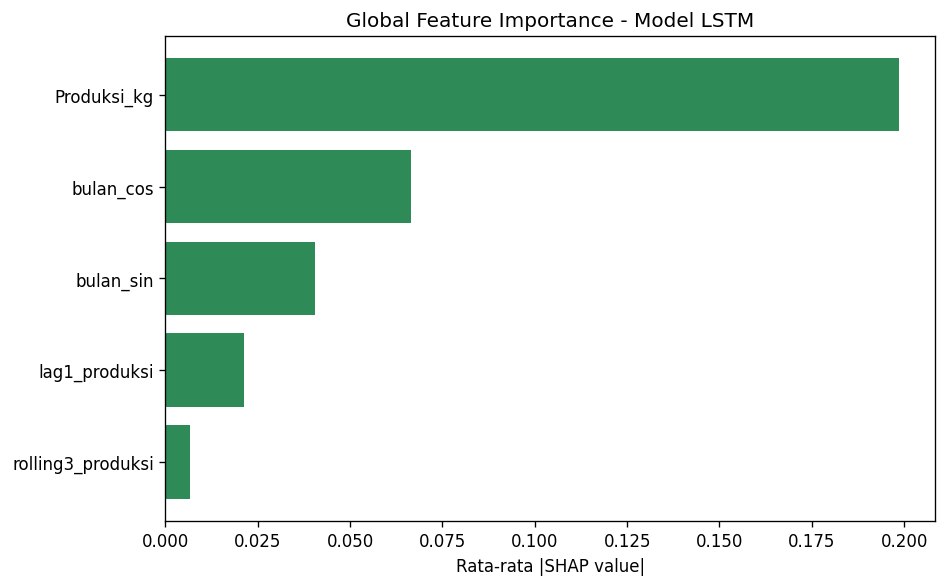

In [115]:
# --- 16.2 Global feature importance (dirata-ratakan lintas sampel & timestep) -
from IPython.display import Image, display
import pandas as pd
import matplotlib.pyplot as plt

global_png = ARTIFACT_DIR / 'shap_global_importance.png'
csv_path = ARTIFACT_DIR / 'shap_feature_importance.csv'

importance_per_fitur = np.abs(shap_values).mean(axis=(0, 1))
fitur_plot = list(FEATURE_NAMES_SHAP)[:len(importance_per_fitur)]
if len(fitur_plot) < len(importance_per_fitur):
    fitur_plot += [f'fitur_{i}' for i in range(len(fitur_plot), len(importance_per_fitur))]
df_importance = pd.DataFrame({'Fitur': fitur_plot, 'Importance': importance_per_fitur}).sort_values('Importance', ascending=False)
df_importance.to_csv(csv_path, index=False)

plt.figure(figsize=(8, 5))
plt.barh(df_importance['Fitur'], df_importance['Importance'], color='seagreen')
plt.xlabel('Rata-rata |SHAP value|')
plt.title('Global Feature Importance - Model LSTM')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.savefig(global_png, dpi=120, bbox_inches='tight')
plt.show()

print('File gambar:', global_png)
print('File tabel  :', csv_path)
print()
print(df_importance.to_string(index=False))
display(Image(filename=str(global_png)))


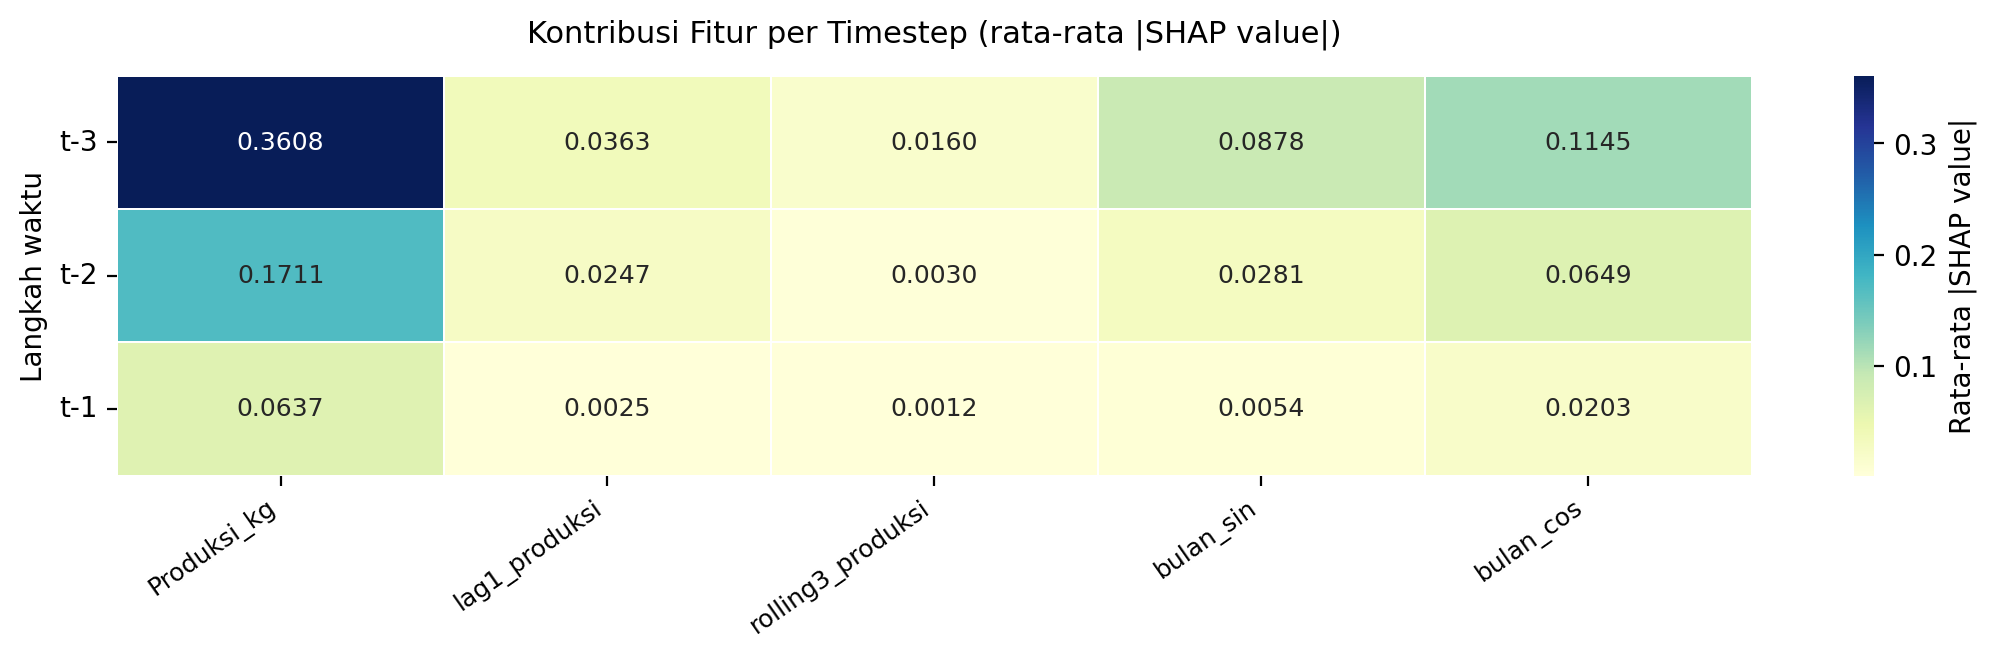


=== Kontribusi per timestep (fitur numerik) ===
     Produksi_kg  lag1_produksi  rolling3_produksi  bulan_sin  bulan_cos
t-3       0.3608         0.0363             0.0160     0.0878     0.1145
t-2       0.1711         0.0247             0.0030     0.0281     0.0649
t-1       0.0637         0.0025             0.0012     0.0054     0.0203

Total kontribusi per timestep:
t-3    0.6155
t-2    0.2918
t-1    0.0931


In [116]:
# --- 16.3 Kontribusi fitur per timestep (versi siap cetak) -------------------
from IPython.display import Image, display

importance_per_timestep = np.abs(shap_values).mean(axis=0)   # (timestep, fitur)
fitur_ts = list(FEATURE_NAMES_SHAP)[:importance_per_timestep.shape[1]]
if len(fitur_ts) < importance_per_timestep.shape[1]:
    fitur_ts += [f'fitur_{i}' for i in range(len(fitur_ts), importance_per_timestep.shape[1])]
df_ts = pd.DataFrame(importance_per_timestep, columns=fitur_ts,
                     index=[f't-{TIMESTEP-i}' for i in range(TIMESTEP)])

# Pisahkan fitur numerik dari kolom identitas one-hot
kol_numerik = [c for c in fitur_ts if not c.startswith('komoditas_oh_')]
kol_onehot  = [c for c in fitur_ts if c.startswith('komoditas_oh_')]

df_ts_ringkas = df_ts[kol_numerik].copy()
if kol_onehot:
    df_ts_ringkas['Identitas komoditas\n(rata-rata kolom one-hot)'] = df_ts[kol_onehot].mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 3.4))
sns.heatmap(
    df_ts_ringkas,
    annot=True,
    fmt='.4f',
    cmap='YlGnBu',
    linewidths=0.7,
    linecolor='white',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Rata-rata |SHAP value|'},
    ax=ax,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_ylabel('Langkah waktu')
ax.set_title('Kontribusi Fitur per Timestep (rata-rata |SHAP value|)', fontsize=11, pad=12)
fig.tight_layout()
out_png = Path(ARTIFACT_DIR) / 'shap_per_timestep.png'
fig.savefig(out_png, dpi=200, bbox_inches='tight')
plt.show()
display(Image(filename=str(out_png)))
plt.close(fig)

if not SHAP_AVAILABLE:
    print('Catatan: tabel bernilai 0 karena SHAP tidak tersedia di environment ini.')
print()
print('=== Kontribusi per timestep (fitur numerik) ===')
print(df_ts_ringkas.round(4).to_string())
print()
print('Total kontribusi per timestep:')
print(df_ts.sum(axis=1).round(4).to_string())


## 17. Penyimpanan Model Terbaik & Fungsi Inferensi


In [117]:
# --- 17.1 Simpan model, evaluasi, dan konfigurasi akhir ----------------------
from pathlib import Path
import json
import pandas as pd

ARTIFACT_DIR = Path(ARTIFACT_DIR)
model_path = ARTIFACT_DIR / 'ensemble_model_revisi.pkl'
if not model_path.exists():
    raise FileNotFoundError(f'Model ensemble tidak ditemukan: {model_path}. Jalankan sel 14.1 dulu.')

eval_path = ARTIFACT_DIR / 'tabel_evaluasi_ensemble_revisi.csv'
if not eval_path.exists():
    raise FileNotFoundError(f'Tabel evaluasi ensemble tidak ditemukan: {eval_path}. Jalankan sel 14.1 dulu.')

df_eval_final = pd.read_csv(eval_path)
df_eval_final.to_csv(ARTIFACT_DIR / 'tabel_evaluasi_final.csv', index=False)

pred_path = ARTIFACT_DIR / 'hasil_prediksi_ensemble_revisi.csv'
if pred_path.exists():
    hasil_prediksi = pd.read_csv(pred_path)
    hasil_prediksi.to_csv(ARTIFACT_DIR / 'hasil_prediksi_test.csv', index=False)

if 'df_importance' in globals():
    df_importance.to_csv(ARTIFACT_DIR / 'shap_feature_importance.csv', index=False)

konfigurasi_final = {
    'source': 'ensemble-baseline-revisi',
    'artifact_model': str(model_path),
    'timestep': 3,
    'min_positive_observations': 30,
    'evaluasi_test': df_eval_final[df_eval_final['split'] == 'Test'].iloc[0].to_dict(),
}
with open(ARTIFACT_DIR / 'konfigurasi_model_final.json', 'w') as f:
    json.dump(konfigurasi_final, f, indent=2, default=str)

print('Artefak final tersimpan di:', ARTIFACT_DIR)
print(df_eval_final.to_string(index=False))
print('File tersedia:')
print(sorted([x.name for x in ARTIFACT_DIR.iterdir()]))


Artefak final tersimpan di: /Users/santi/Documents/JOKI/joki-1376/revisi-agropredict-lstm-dashboard/program_colabs/artefak_model
     split   MAPE(%)     RMSE(kg)       R2
     Train 56.683565 70689.830760 0.006697
Validation 33.485604 16819.264381 0.897846
      Test 39.233828 43537.529339 0.642826
File tersedia:
['K_test.npy', 'K_train.npy', 'K_val.npy', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'aktual_vs_prediksi_revisi.png', 'data_produksi_gabungan_clean.csv', 'data_produksi_gabungan_raw.csv', 'dataset_final_raw.csv', 'dataset_final_scaled.csv', 'eda_boxplot_per_komoditas.png', 'eda_distribusi_produksi.png', 'eda_korelasi.png', 'eda_proporsi_nol.png', 'eda_timeseries_contoh.png', 'ensemble_model_revisi.pkl', 'feature_list.json', 'hasil_prediksi_ensemble_revisi.csv', 'hasil_prediksi_lstm_revisi.csv', 'hasil_prediksi_test.csv', 'hasil_tuning_lstm_revisi.csv', 'history_lstm_revisi.csv', 'komoditas_dibuang_model.csv', 'komoditas_dipakai_model.csv', 'komoditas_mapping.json', 'konfigura

In [118]:
# --- 17.2 Fungsi inferensi siap pakai untuk Streamlit ------------------------
from pathlib import Path
import pickle

ENSEMBLE_MODEL_PATH = Path(ARTIFACT_DIR) / 'ensemble_model_revisi.pkl'
if not ENSEMBLE_MODEL_PATH.exists():
    raise FileNotFoundError(f'Model ensemble tidak ditemukan: {ENSEMBLE_MODEL_PATH}. Jalankan sel 14.1 dulu.')

with open(ENSEMBLE_MODEL_PATH, 'rb') as f:
    _ensemble_payload = pickle.load(f)

_choice_map = {row['Nama']: row['metode_terpilih'] for row in _ensemble_payload.get('choices', [])}

def _next_period_from_history(df_hist: pd.DataFrame) -> pd.Timestamp:
    if 'Periode' in df_hist.columns:
        last_period = pd.to_datetime(df_hist['Periode']).max()
        return last_period + pd.offsets.MonthBegin(1)
    return pd.Timestamp.today().normalize()

def _predict_ensemble_from_history(df_hist: pd.DataFrame, nama_komoditas: str) -> float:
    if 'Produksi_kg' not in df_hist.columns:
        raise ValueError('Data input harus memiliki kolom Produksi_kg.')
    if len(df_hist) == 0:
        return 0.0

    g = df_hist.copy()
    if 'Periode' in g.columns:
        g = g.sort_values('Periode')
    y = pd.to_numeric(g['Produksi_kg'], errors='coerce').fillna(0).to_numpy(dtype=float)
    if len(y) == 0:
        return 0.0

    method = _choice_map.get(nama_komoditas, 'rolling3')
    last = float(y[-1])
    last3 = y[-3:] if len(y) >= 3 else y
    pos = y[y > 0]
    month_mask = None
    if 'Periode' in g.columns:
        next_month = _next_period_from_history(g).month
        bulan_hist = pd.to_datetime(g['Periode']).dt.month.to_numpy()
        month_mask = bulan_hist == next_month

    def _safe_mean(arr, fallback=0.0):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        return float(arr.mean()) if len(arr) else float(fallback)

    def _safe_median(arr, fallback=0.0):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        return float(np.median(arr)) if len(arr) else float(fallback)

    if method == 'lag1':
        pred = last
    elif method == 'rolling3':
        pred = _safe_mean(last3, fallback=last)
    elif method == 'last_nonzero':
        nz = y[y > 0]
        pred = float(nz[-1]) if len(nz) else 0.0
    elif method == 'seasonal_median':
        if month_mask is not None and month_mask.any():
            pred = _safe_median(y[month_mask], fallback=_safe_median(y, fallback=last))
        else:
            pred = _safe_median(y, fallback=last)
    elif method == 'seasonal_pos_median':
        if month_mask is not None and month_mask.any():
            month_pos = y[month_mask]
            month_pos = month_pos[month_pos > 0]
            pred = _safe_median(month_pos, fallback=_safe_median(pos, fallback=last))
        else:
            pred = _safe_median(pos, fallback=last)
    elif method == 'train_median_pos':
        pred = _safe_median(pos, fallback=last)
    elif method == 'train_mean_pos':
        pred = _safe_mean(pos, fallback=last)
    elif method == 'blend_roll_season':
        roll = _safe_mean(last3, fallback=last)
        sea = _safe_median(pos if len(pos) else y, fallback=last)
        pred = 0.5 * roll + 0.5 * sea
    elif method == 'blend_lag_roll':
        roll = _safe_mean(last3, fallback=last)
        pred = 0.5 * last + 0.5 * roll
    elif method == 'zero':
        pred = 0.0
    else:
        pred = _safe_mean(last3, fallback=last)

    return float(max(pred, 0.0))

def prediksi_produksi(data_3_bulan_terakhir: pd.DataFrame, nama_komoditas: str,
                       model=None, scaler_dict=None, label_encoder=None,
                       onehot_encoder=None, fitur_dasar=None, target_idx=None,
                       timestep=TIMESTEP, encoding=ENCODING_TERBAIK, pakai_embedding=PAKAI_EMBEDDING):
    '''Prediksi produksi bulan berikutnya untuk 1 komoditas.'''
    if nama_komoditas not in _choice_map:
        print(f'Perhatian: komoditas "{nama_komoditas}" tidak ada di artefak ensemble, pakai fallback rolling3.')
    return _predict_ensemble_from_history(data_3_bulan_terakhir, nama_komoditas)

# Contoh pemakaian: pilih otomatis komoditas yang benar-benar ada di artefak ensemble.
komoditas_tersedia_model = sorted(_choice_map.keys())
print('Komoditas yang tersedia di artefak ensemble:')
print(komoditas_tersedia_model)

prioritas_contoh = ['Cabai Keriting', 'Wortel', 'Cabai Rawit', 'Bawang Merah']
contoh_nama = next((k for k in prioritas_contoh if k in _choice_map), komoditas_tersedia_model[0])
contoh_data = df[(df['Nama'] == contoh_nama)].sort_values('Periode').tail(12)

try:
    hasil_contoh = prediksi_produksi(contoh_data, contoh_nama)
    print(f'Encoding yang dipakai: {ENCODING_TERBAIK}')
    print(f'Contoh prediksi produksi {contoh_nama} bulan berikutnya: {hasil_contoh:,.1f} kg')
except Exception as e:
    print('Contoh gagal (cek data):', e)


Komoditas yang tersedia di artefak ensemble:
['Bawang Daun', 'Buncis', 'Cabai Besar', 'Cabai Keriting', 'Cabai Rawit', 'Kembang Kol', 'Kubis', 'Labu Siam', 'Tomat']
Encoding yang dipakai: One-Hot Encoding
Contoh prediksi produksi Cabai Keriting bulan berikutnya: 104,500.0 kg


# Perbandingan SimpleRNN vs GRU vs LSTM


In [119]:
# --- L.1 Perbandingan SimpleRNN vs GRU vs LSTM (3 pengulangan seed) ---------
import time
from tensorflow.keras.layers import GRU, SimpleRNN

# Fallback hyperparameter final: ambil dari hasil tuner kalau ada, kalau tidak pakai hasil 13.3/default aman.
if 'best_hp' in globals() and best_hp is not None and globals().get('GUNAKAN_HASIL_TUNER', False):
    FINAL_UNITS = int(best_hp.values.get('units', globals().get('BEST_UNITS', 64)))
    FINAL_DROPOUT = float(best_hp.values.get('dropout', 0.2))
    FINAL_NLAYER = int(best_hp.values.get('n_layer', 1))
    FINAL_LR = float(best_hp.values.get('learning_rate', 0.001))
    FINAL_OPT = best_hp.values.get('optimizer_name', 'adam')
    FINAL_BATCH = int(best_hp.values.get('batch_size', 16))
else:
    FINAL_UNITS = int(globals().get('BEST_UNITS', 64))
    FINAL_DROPOUT = float(globals().get('FINAL_DROPOUT', 0.2))
    FINAL_NLAYER = int(globals().get('FINAL_NLAYER', 1))
    FINAL_LR = float(globals().get('FINAL_LR', 0.001))
    FINAL_OPT = globals().get('FINAL_OPT', 'adam')
    FINAL_BATCH = int(globals().get('FINAL_BATCH', 16))

def _ambil_dataset_aktif_untuk_pembanding():
    encoding_aktif = globals().get('ENCODING_TERBAIK', 'One-Hot Encoding')
    if encoding_aktif == 'Label Encoding' and 'dataset_label' in globals():
        return {
            'X_train': dataset_label['X_train'], 'y_train': dataset_label['y_train'], 'K_train': dataset_label['K_train'],
            'X_val': dataset_label['X_val'], 'y_val': dataset_label['y_val'], 'K_val': dataset_label['K_val'],
            'X_test': dataset_label['X_test'], 'y_test': dataset_label['y_test'], 'K_test': dataset_label['K_test'],
            'features': FEATURES_LABEL, 'pakai_embedding': False, 'encoding': encoding_aktif,
        }
    if encoding_aktif == 'One-Hot Encoding' and 'dataset_onehot' in globals():
        return {
            'X_train': dataset_onehot['X_train'], 'y_train': dataset_onehot['y_train'], 'K_train': dataset_onehot['K_train'],
            'X_val': dataset_onehot['X_val'], 'y_val': dataset_onehot['y_val'], 'K_val': dataset_onehot['K_val'],
            'X_test': dataset_onehot['X_test'], 'y_test': dataset_onehot['y_test'], 'K_test': dataset_onehot['K_test'],
            'features': FEATURES_ONEHOT, 'pakai_embedding': False, 'encoding': encoding_aktif,
        }

    # Fallback untuk Embedding: pakai array aktif hanya kalau train/val/test benar-benar konsisten.
    def _valid_split(Xa, ya, Ka):
        return (
            np.asarray(Xa).ndim == 3
            and len(Xa) == len(ya) == len(Ka)
            and np.asarray(Xa).shape[1] == TIMESTEP
            and np.asarray(Xa).shape[2] == len(globals().get('FEATURES_EMBED', globals().get('FEATURES', [])))
        )

    if all(name in globals() for name in ['X_train', 'y_train', 'K_train', 'X_val', 'y_val', 'K_val', 'X_test', 'y_test', 'K_test']) and \
       _valid_split(X_train, y_train, K_train) and _valid_split(X_val, y_val, K_val) and _valid_split(X_test, y_test, K_test):
        return {
            'X_train': np.asarray(X_train), 'y_train': np.asarray(y_train), 'K_train': np.asarray(K_train),
            'X_val': np.asarray(X_val), 'y_val': np.asarray(y_val), 'K_val': np.asarray(K_val),
            'X_test': np.asarray(X_test), 'y_test': np.asarray(y_test), 'K_test': np.asarray(K_test),
            'features': globals().get('FEATURES_EMBED', globals().get('FEATURES_AKTIF', [])),
            'pakai_embedding': True, 'encoding': encoding_aktif,
        }

    # Kalau state kernel sudah tercampur oleh SHAP/one-hot, bangun ulang dataset embedding 5 fitur dari artefak revisi.
    import runpy
    ns_rnn = runpy.run_path(str(BASE_DIR / 'train_lstm_revisi_data_produksi.py'))
    df_rnn = ns_rnn['split_by_commodity'](ns_rnn['add_features'](ns_rnn['load_clean']()))
    x_scaler_rnn, y_scaler_rnn = ns_rnn['fit_scalers'](df_rnn)
    arrays_rnn = ns_rnn['build_arrays'](df_rnn, x_scaler_rnn, y_scaler_rnn)
    fitur_rnn = list(ns_rnn['FEATURE_SEQ'] + ns_rnn['FEATURE_EXTRA'])
    return {
        'X_train': arrays_rnn['X_train'], 'y_train': arrays_rnn['y_train'], 'K_train': arrays_rnn['K_train'],
        'X_val': arrays_rnn['X_val'], 'y_val': arrays_rnn['y_val'], 'K_val': arrays_rnn['K_val'],
        'X_test': arrays_rnn['X_test'], 'y_test': arrays_rnn['y_test'], 'K_test': arrays_rnn['K_test'],
        'features': fitur_rnn, 'pakai_embedding': True, 'encoding': 'Embedding (artefak konsisten)',
    }

_data_rnn = _ambil_dataset_aktif_untuk_pembanding()
X_train_final = _data_rnn['X_train']
y_train_final = _data_rnn['y_train']
K_train_final = _data_rnn['K_train']
X_val_rnn, y_val_rnn, K_val_rnn = _data_rnn['X_val'], _data_rnn['y_val'], _data_rnn['K_val']
X_test_rnn, y_test_rnn, K_test_rnn = _data_rnn['X_test'], _data_rnn['y_test'], _data_rnn['K_test']
PAKAI_EMBEDDING_RNN = _data_rnn['pakai_embedding']
N_FITUR_SEQUENCE = int(X_train_final.shape[2])

print(f'Dataset pembanding: {_data_rnn["encoding"]} | X_train={X_train_final.shape}, X_val={X_val_rnn.shape}, X_test={X_test_rnn.shape}, y_train={y_train_final.shape}, pakai_embedding={PAKAI_EMBEDDING_RNN}')

def _format_input_rnn(X_arr, K_arr):
    return format_input(X_arr, K_arr, PAKAI_EMBEDDING_RNN)

def _predict_array_for_eval(model, X_arr, K_arr):
    pred = model.predict(_format_input_rnn(X_arr, K_arr), verbose=0)
    if isinstance(pred, (list, tuple)):
        pred = pred[0]
    return np.asarray(pred).reshape(-1, 1)

def _evaluasi_rnn(model, X_arr, y_arr, K_arr):
    pred_scaled = _predict_array_for_eval(model, X_arr, K_arr)
    actual = inverse_target_per_komoditas(y_arr, K_arr)
    pred = inverse_target_per_komoditas(pred_scaled, K_arr)
    med_mape, _ = median_mape_per_komoditas(actual, pred, K_arr)
    return {
        'MAPE(%)': hitung_mape(actual, pred),
        'MedianMAPE(%)': med_mape,
        'RMSE(kg)': hitung_rmse(actual, pred),
        'R2': r2_score(actual, pred),
    }

RNN_PEMBANDING = {'SimpleRNN': SimpleRNN, 'GRU': GRU, 'LSTM': LSTM}
N_REPEAT_RNN = 3
hasil_run = []

print('Hyperparameter pembanding:')
print(f'  units={FINAL_UNITS}, layer={FINAL_NLAYER}, dropout={FINAL_DROPOUT}, lr={FINAL_LR}, optimizer={FINAL_OPT}, batch={FINAL_BATCH}')
print('Catatan: MAPE rata-rata pada data ini sangat sensitif terhadap produksi aktual nol/kecil.')
print('Untuk pembanding arsitektur, MedianMAPE dipakai sebagai indikator utama yang lebih stabil.')

for rnn_type in ['SimpleRNN', 'GRU', 'LSTM']:
    for r in range(N_REPEAT_RNN):
        seed_run = SEED + r
        tf.random.set_seed(seed_run); np.random.seed(seed_run)
        if PAKAI_EMBEDDING_RNN:
            model = bangun_model_embedding(units=FINAL_UNITS, dropout=FINAL_DROPOUT,
                                          n_fitur=N_FITUR_SEQUENCE, n_komoditas=N_KOMODITAS,
                                          rnn_layer=RNN_PEMBANDING[rnn_type],
                                          learning_rate=FINAL_LR, optimizer_name=FINAL_OPT)
        else:
            model = bangun_model(units=FINAL_UNITS, dropout=FINAL_DROPOUT, n_layer=FINAL_NLAYER,
                                 n_fitur=N_FITUR_SEQUENCE, rnn_layer=RNN_PEMBANDING[rnn_type],
                                 learning_rate=FINAL_LR, optimizer_name=FINAL_OPT)
        es = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
        t0 = time.time()
        hist = model.fit(_format_input_rnn(X_train_final, K_train_final), y_train_final,
                         validation_data=(_format_input_rnn(X_val_rnn, K_val_rnn), y_val_rnn),
                         epochs=200, batch_size=FINAL_BATCH, callbacks=[es], verbose=0)
        waktu = time.time() - t0

        h_vl = _evaluasi_rnn(model, X_val_rnn, y_val_rnn, K_val_rnn)
        h_ts = _evaluasi_rnn(model, X_test_rnn, y_test_rnn, K_test_rnn)

        hasil_run.append({
            'Model': rnn_type, 'seed': seed_run,
            'Val_MAPE': h_vl['MAPE(%)'], 'Test_MAPE': h_ts['MAPE(%)'],
            'Test_MedianMAPE': h_ts['MedianMAPE(%)'],
            'Test_RMSE': h_ts['RMSE(kg)'], 'Test_R2': h_ts['R2'],
            'Waktu(s)': round(waktu, 1), 'Epoch': len(hist.history['loss']),
            'Parameter': model.count_params(),
        })
        print(f'{rnn_type:10s} seed={seed_run} | Test MedianMAPE={h_ts["MedianMAPE(%)"]:6.2f}% | '
              f'MAPE diagnostik={h_ts["MAPE(%)"]:7.2f}% | R2={h_ts["R2"]:6.3f} | {waktu:.0f}s')

df_run = pd.DataFrame(hasil_run)
df_perbandingan = df_run.groupby('Model').agg(
    Test_MedianMAPE_mean=('Test_MedianMAPE', 'mean'),
    Test_MedianMAPE_std=('Test_MedianMAPE', 'std'),
    Test_R2_mean=('Test_R2', 'mean'),
    Test_RMSE_mean=('Test_RMSE', 'mean'),
    Test_MAPE_diagnostik_mean=('Test_MAPE', 'mean'),
    Test_MAPE_diagnostik_std=('Test_MAPE', 'std'),
    Waktu_mean=('Waktu(s)', 'mean'), Parameter=('Parameter', 'first')
).sort_values('Test_MedianMAPE_mean').round(3)

df_run_tampil = df_run.rename(columns={
    'Val_MAPE': 'Val_MAPE_diagnostik',
    'Test_MAPE': 'Test_MAPE_diagnostik',
    'Test_MedianMAPE': 'Test_MedianMAPE_utama',
})

print('\n=== TABEL PERBANDINGAN ARSITEKTUR (rata-rata 3 seed, diurutkan MedianMAPE) ===')
print(df_perbandingan.to_string())
print('\nCatatan: kolom MAPE_diagnostik bisa tinggi karena banyak aktual nol/kecil; gunakan MedianMAPE dan R2 untuk membaca stabilitas arsitektur.')
print('\n=== Rincian per seed (untuk lampiran) ===')
print(df_run_tampil.round(3).to_string(index=False))

df_perbandingan.to_csv(f'{ARTIFACT_DIR}/tabel_perbandingan_model.csv')
df_run.to_csv(f'{ARTIFACT_DIR}/perbandingan_model_per_seed.csv', index=False)


Dataset pembanding: One-Hot Encoding | X_train=(572, 3, 35), X_val=(52, 3, 35), X_test=(78, 3, 35), y_train=(572,), pakai_embedding=False
Hyperparameter pembanding:
  units=64, layer=2, dropout=0.2, lr=0.01, optimizer=adam, batch=32
Catatan: MAPE rata-rata pada data ini sangat sensitif terhadap produksi aktual nol/kecil.
Untuk pembanding arsitektur, MedianMAPE dipakai sebagai indikator utama yang lebih stabil.
SimpleRNN  seed=42 | Test MedianMAPE= 26.44% | MAPE diagnostik=  84.39% | R2= 0.869 | 4s
SimpleRNN  seed=43 | Test MedianMAPE= 33.18% | MAPE diagnostik= 175.67% | R2= 0.820 | 4s
SimpleRNN  seed=44 | Test MedianMAPE= 33.24% | MAPE diagnostik= 114.25% | R2= 0.818 | 5s
GRU        seed=42 | Test MedianMAPE= 27.09% | MAPE diagnostik=  84.97% | R2= 0.678 | 8s
GRU        seed=43 | Test MedianMAPE= 34.78% | MAPE diagnostik=  86.99% | R2= 0.803 | 9s
GRU        seed=44 | Test MedianMAPE= 38.22% | MAPE diagnostik=  93.90% | R2= 0.807 | 8s
LSTM       seed=42 | Test MedianMAPE= 25.00% | MAPE 